# River Basin Land Use Change Analysis
## Using Google Earth Engine Dynamic World

This notebook analyzes land use changes in a river basin using:
- Dynamic World land cover classification
- Split map visualization for comparing two years
- Quantitative land use change statistics

In [1]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

# Initialize Earth Engine
ee.Initialize()

## Configuration
Set your parameters here:

In [2]:
# Path to river basin shapefile
SHAPEFILE_PATH = "basin.shp"

# Path to river line shapefile
RIVER_SHAPEFILE_PATH = "mara-river.shp"

# Years to compare
YEAR_1 = 2015
YEAR_2 = 2025

# Styling
BASIN_COLOR = '#000000'  # White for basin boundary
RIVER_COLOR = '#0000CD'  # Medium blue - distinct from water class (#419BDF)

# Dynamic World class names and colors
DW_CLASSES = {
    0: {'name': 'Water', 'color': '#419BDF'},
    1: {'name': 'Trees', 'color': '#397D49'},
    2: {'name': 'Grass', 'color': '#88B053'},
    3: {'name': 'Flooded Vegetation', 'color': '#7A87C6'},
    4: {'name': 'Crops', 'color': '#E49635'},
    5: {'name': 'Shrub & Scrub', 'color': '#DFC35A'},
    6: {'name': 'Built Area', 'color': '#C4281B'},
    7: {'name': 'Bare Ground', 'color': '#A59B8F'},
    8: {'name': 'Snow & Ice', 'color': '#B39FE1'}
}

## Additional Features (Basin-Specific)
Define optional features like mines, factories, wetlands, protected areas, etc. that are relevant for this specific basin.
Each feature needs a path to a GeoJSON/shapefile, a display name, and styling options.

In [5]:
# Additional features configuration
# Add basin-specific features here. Set to empty list [] if no additional features.
# Each feature should have:
#   - path: path to GeoJSON or shapefile
#   - name: display name for legend
#   - color: hex color code
#   - type: 'point', 'line', or 'polygon'
#   - icon: (optional) for points - 'circle', 'square', 'star', 'triangle' (default: 'circle')
#   - size: (optional) for points - marker size in pixels (default: 8)

ADDITIONAL_FEATURES = [
    # Example configurations (uncomment and modify as needed):
    #
    # {
    #     'path': 'gold_mines.geojson',
    #     'name': 'Gold Mines',
    #     'color': '#FFD700',
    #     'type': 'point',
    #     'icon': 'square',
    #     'size': 10
    # },
    # {
    #     'path': 'factories.geojson',
    #     'name': 'Factories',
    #     'color': '#FF4500',
    #     'type': 'point',
    #     'icon': 'triangle',
    #     'size': 12
    # },
    # {
    #     'path': 'wetlands.geojson',
    #     'name': 'Wetlands',
    #     'color': '#00CED1',
    #     'type': 'polygon',
    #     'fill_opacity': 0.3
    # },
    # {
    #     'path': 'protected_areas.shp',
    #     'name': 'Protected Areas',
    #     'color': '#228B22',
    #     'type': 'polygon',
    #     'fill_opacity': 0.2
    # },
]

print(f"Additional features configured: {len(ADDITIONAL_FEATURES)}")
for feat in ADDITIONAL_FEATURES:
    print(f"  - {feat['name']} ({feat['type']}): {feat['path']}")

Additional features configured: 0


## Load River Basin Boundary

In [3]:
# Load shapefile as Earth Engine geometry
# Option 1: From local shapefile
basin_gdf = geemap.shp_to_gdf(SHAPEFILE_PATH)
basin_ee = geemap.gdf_to_ee(basin_gdf)

# Load river shapefile
river_gdf = geemap.shp_to_gdf(RIVER_SHAPEFILE_PATH)
river_ee_raw = geemap.gdf_to_ee(river_gdf)

# Option 2: Use an existing GEE asset (uncomment if using asset)
# basin_ee = ee.FeatureCollection('users/your_username/your_basin_asset')
# river_ee_raw = ee.FeatureCollection('users/your_username/your_river_asset')

# Get the basin geometry
roi = basin_ee.geometry()

# Clip river to basin extent
def clip_to_basin(feature):
    return feature.intersection(roi, ee.ErrorMargin(1))

river_ee = river_ee_raw.map(clip_to_basin)

print(f"Basin area: {roi.area().divide(1e6).getInfo():.2f} sq km")
print(f"River features (raw): {river_ee_raw.size().getInfo()}")
print(f"River features (clipped to basin): {river_ee.size().getInfo()}")

Basin area: 13571.52 sq km
River features (raw): 61
River features (clipped to basin): 61


In [6]:
# Load additional features
import geopandas as gpd
from pathlib import Path

def load_additional_feature(feature_config, basin_geometry):
    """
    Load a feature from GeoJSON or shapefile and convert to Earth Engine.
    Clips to basin boundary.
    """
    path = feature_config['path']
    
    # Load based on file extension
    if path.endswith('.geojson') or path.endswith('.json'):
        gdf = gpd.read_file(path)
    elif path.endswith('.shp'):
        gdf = geemap.shp_to_gdf(path)
    else:
        raise ValueError(f"Unsupported file format: {path}")
    
    # Convert to Earth Engine
    ee_feature = geemap.gdf_to_ee(gdf)
    
    # Clip to basin if it's a polygon or line type
    if feature_config.get('type') in ['polygon', 'line']:
        def clip_feature(f):
            return f.intersection(basin_geometry, ee.ErrorMargin(1))
        ee_feature = ee_feature.map(clip_feature)
    
    return {
        'ee': ee_feature,
        'gdf': gdf,
        **feature_config
    }

# Load all additional features
loaded_features = []
for feat_config in ADDITIONAL_FEATURES:
    try:
        if Path(feat_config['path']).exists():
            loaded = load_additional_feature(feat_config, roi)
            loaded_features.append(loaded)
            print(f"Loaded: {feat_config['name']} ({loaded['ee'].size().getInfo()} features)")
        else:
            print(f"Warning: File not found - {feat_config['path']}")
    except Exception as e:
        print(f"Error loading {feat_config['name']}: {e}")

print(f"\nSuccessfully loaded {len(loaded_features)} additional feature(s)")


Successfully loaded 0 additional feature(s)


## Get Dynamic World Land Cover for Both Years

In [7]:
def get_dynamic_world_mode(year, roi):
    """
    Get the mode (most frequent) land cover class for a given year.
    Uses annual composite to reduce noise.
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    # Load Dynamic World collection
    dw = ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1') \
        .filterDate(start_date, end_date) \
        .filterBounds(roi)
    
    # Get the mode of the 'label' band (most frequent class)
    classification = dw.select('label').mode().clip(roi)
    
    return classification

# Get land cover for both years
lc_year1 = get_dynamic_world_mode(YEAR_1, roi)
lc_year2 = get_dynamic_world_mode(YEAR_2, roi)

print(f"Land cover data loaded for {YEAR_1} and {YEAR_2}")

Land cover data loaded for 2015 and 2025


## Create Split Map Visualization

In [8]:
# Define visualization parameters for Dynamic World
dw_vis = {
    'min': 0,
    'max': 8,
    'palette': [v['color'] for v in DW_CLASSES.values()]
}

# Create split map (hide layer selector and toolbar)
split_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)

# Add layers for split view
left_layer = geemap.ee_tile_layer(lc_year1, dw_vis, f'Land Cover {YEAR_1}')
right_layer = geemap.ee_tile_layer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

split_map.split_map(left_layer, right_layer)

# Center map on the basin
split_map.centerObject(roi, zoom=10)

# Add river
split_map.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
split_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}), 
    {}, 
    'Basin Boundary'
)

# Add additional features to map
for feature in loaded_features:
    feat_type = feature.get('type', 'point')
    color = feature['color']
    name = feature['name']
    
    if feat_type == 'point':
        # Style points with circle markers
        size = feature.get('size', 8)
        styled = feature['ee'].style(**{
            'color': color,
            'pointSize': size,
            'width': 1
        })
    elif feat_type == 'line':
        styled = feature['ee'].style(**{
            'color': color,
            'width': 2
        })
    else:  # polygon
        fill_opacity = feature.get('fill_opacity', 0.3)
        # Convert fill opacity to hex alpha
        alpha_hex = format(int(fill_opacity * 255), '02x')
        fill_color = color + alpha_hex if len(color) == 7 else color[:7] + alpha_hex
        styled = feature['ee'].style(**{
            'color': color,
            'fillColor': fill_color,
            'width': 2
        })
    
    split_map.addLayer(styled, {}, name)

# Add legends
legend_labels = [v['name'] for v in DW_CLASSES.values()]
legend_colors = [v['color'] for v in DW_CLASSES.values()]
split_map.add_legend(title='Land Cover Classes', keys=legend_labels, colors=legend_colors)

# Build reference legend including additional features
reference_keys = ['Basin Boundary', 'River'] + [f['name'] for f in loaded_features]
reference_colors = [BASIN_COLOR, RIVER_COLOR] + [f['color'] for f in loaded_features]
split_map.add_legend(keys=reference_keys, colors=reference_colors, position='topright')

split_map

Map(center=[-1.3843255052810637, 35.071029768653396], controls=(ZoomControl(options=['position', 'zoom_in_text…

## Export Split Map to HTML
Save the split map as an HTML file for use in Streamlit.

## Download Land Cover Tiles (Optional)
Run this cell to download tiles locally for offline use. Only needs to be run once per basin/year configuration.

In [29]:
# Download tiles for offline use
import os
import requests
import math
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm

def deg2num(lat_deg, lon_deg, zoom):
    """Convert lat/lon to tile numbers"""
    lat_rad = math.radians(lat_deg)
    n = 2.0 ** zoom
    xtile = int((lon_deg + 180.0) / 360.0 * n)
    ytile = int((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return (xtile, ytile)

def download_tile(args):
    """Download a single tile"""
    url, save_path = args
    try:
        if os.path.exists(save_path):
            return True, save_path
        
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
        }
        response = requests.get(url, timeout=30, headers=headers)
        if response.status_code == 200:
            os.makedirs(os.path.dirname(save_path), exist_ok=True)
            with open(save_path, 'wb') as f:
                f.write(response.content)
            return True, save_path
        return False, f"HTTP {response.status_code}"
    except Exception as e:
        return False, str(e)

def download_tiles_for_bounds(tile_url_template, bounds, zoom_levels, output_dir, name):
    """Download all tiles within bounds for specified zoom levels"""
    min_lat, min_lon, max_lat, max_lon = bounds
    
    tiles_to_download = []
    for zoom in zoom_levels:
        min_tile = deg2num(max_lat, min_lon, zoom)  # Note: max_lat gives min y tile
        max_tile = deg2num(min_lat, max_lon, zoom)
        
        for x in range(min_tile[0], max_tile[0] + 1):
            for y in range(min_tile[1], max_tile[1] + 1):
                url = tile_url_template.replace('{z}', str(zoom)).replace('{x}', str(x)).replace('{y}', str(y))
                save_path = os.path.join(output_dir, name, str(zoom), str(x), f"{y}.png")
                tiles_to_download.append((url, save_path))
    
    print(f"Downloading {len(tiles_to_download)} tiles for {name}...")
    
    success_count = 0
    with ThreadPoolExecutor(max_workers=10) as executor:
        futures = {executor.submit(download_tile, args): args for args in tiles_to_download}
        for future in tqdm(as_completed(futures), total=len(tiles_to_download), desc=name):
            success, result = future.result()
            if success:
                success_count += 1
    
    print(f"Downloaded {success_count}/{len(tiles_to_download)} tiles for {name}")
    return success_count

# Configuration
TILE_ZOOM_LEVELS = [8, 9, 10, 11, 12]  # Adjust zoom levels as needed
TILES_DIR = os.path.join(OUTPUT_DIR, BASIN_NAME, "tiles")

# Get tile URLs from Earth Engine
def get_ee_tile_url(image, vis_params):
    """Get Earth Engine tile URL for an image"""
    map_id = image.getMapId(vis_params)
    return map_id['tile_fetcher'].url_format

# Generate tile URLs for both years
tile_url_year1 = get_ee_tile_url(lc_year1, dw_vis)
tile_url_year2 = get_ee_tile_url(lc_year2, dw_vis)

# Google Satellite Hybrid URL template
# lyrs=y means satellite with labels (hybrid), lyrs=s is satellite only
BASEMAP_URL = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"

print(f"Tile URLs generated for {YEAR_1} and {YEAR_2}")

# Get bounds
bounds_info = roi.bounds().getInfo()['coordinates'][0]
min_lon = min(p[0] for p in bounds_info)
max_lon = max(p[0] for p in bounds_info)
min_lat = min(p[1] for p in bounds_info)
max_lat = max(p[1] for p in bounds_info)

# Add small buffer to bounds
buffer = 0.01
bounds = (min_lat - buffer, min_lon - buffer, max_lat + buffer, max_lon + buffer)

print(f"Bounds: {bounds}")
print(f"Zoom levels: {TILE_ZOOM_LEVELS}")
print(f"Output directory: {TILES_DIR}")
print()

# Download basemap tiles (Google Satellite Hybrid)
download_tiles_for_bounds(BASEMAP_URL, bounds, TILE_ZOOM_LEVELS, TILES_DIR, "basemap")

# Download land cover tiles for both years
download_tiles_for_bounds(tile_url_year1, bounds, TILE_ZOOM_LEVELS, TILES_DIR, f"landcover_{YEAR_1}")
download_tiles_for_bounds(tile_url_year2, bounds, TILE_ZOOM_LEVELS, TILES_DIR, f"landcover_{YEAR_2}")

print(f"\nTiles saved to: {TILES_DIR}")
print("You can now run the HTML export cell - it will use local tiles.")


# Also download and save land cover raster data for 3D visualization
print("\nDownloading land cover raster data for 3D visualization...")

def download_lc_raster(lc_image, year, output_dir):
    """Download land cover as GeoTIFF raster"""
    from rasterio.io import MemoryFile
    import zipfile
    from io import BytesIO
    
    raster_path = os.path.join(output_dir, f"landcover_{year}_raster.npy")
    
    if os.path.exists(raster_path):
        print(f"  Land cover {year} raster already exists: {raster_path}")
        return raster_path
    
    lc_download_url = lc_image.getDownloadURL({
        'scale': 100,
        'crs': 'EPSG:4326',
        'region': roi,
        'format': 'GEO_TIFF'
    })
    
    response = requests.get(lc_download_url, timeout=120)
    response.raise_for_status()
    content = response.content
    
    # Parse the response
    if content[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(content)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            tif_data = zf.read(tif_name)
    elif content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
        tif_data = content
    else:
        raise ValueError(f"Could not parse Land Cover {year} response")
    
    with MemoryFile(tif_data) as memfile:
        with memfile.open() as src:
            lc_data = src.read(1)
    
    # Save as numpy array
    os.makedirs(output_dir, exist_ok=True)
    np.save(raster_path, lc_data)
    print(f"  Saved land cover {year} raster: {raster_path} ({lc_data.shape})")
    return raster_path

import numpy as np
raster_dir = os.path.join(OUTPUT_DIR, BASIN_NAME, "rasters")
download_lc_raster(lc_year1, YEAR_1, raster_dir)
download_lc_raster(lc_year2, YEAR_2, raster_dir)

print("\nAll downloads complete!")

Tile URLs generated for 2015 and 2025
Bounds: (-1.93083363257213, 33.956667157074115, -0.3691662710357455, 35.8808326536765)
Zoom levels: [8, 9, 10, 11, 12]
Output directory: ../data/mara_basin/tiles



basemap:   0%|          | 0/573 [00:00<?, ?it/s]

Downloaded 573/573 tiles for basemap


landcover_2015:   0%|          | 0/573 [00:00<?, ?it/s]

Downloaded 567/573 tiles for landcover_2015


landcover_2025:   0%|          | 0/573 [00:00<?, ?it/s]

Downloaded 573/573 tiles for landcover_2025

Tiles saved to: ../data/mara_basin/tiles
You can now run the HTML export cell - it will use local tiles.


In [30]:
# Export split map to standalone HTML using folium
import os
import folium
from folium import plugins
from folium.elements import Element
from pathlib import Path

# Define output paths
OUTPUT_DIR = "../data"
BASIN_NAME = "mara_basin"  # Change to 'lower_mara_basin' for the other basin
ZOOM = 9  # Adjust zoom level as needed

# Create output directory if it doesn't exist
output_path = os.path.join(OUTPUT_DIR, BASIN_NAME)
os.makedirs(output_path, exist_ok=True)

# Check if local tiles exist
tiles_dir = os.path.join(output_path, "tiles")
local_tiles_year1 = os.path.join(tiles_dir, f"landcover_{YEAR_1}")
local_tiles_year2 = os.path.join(tiles_dir, f"landcover_{YEAR_2}")
local_basemap = os.path.join(tiles_dir, "basemap")

use_local_tiles = os.path.exists(local_tiles_year1) and os.path.exists(local_tiles_year2)
use_local_basemap = os.path.exists(local_basemap)

if use_local_tiles:
    print(f"Using LOCAL land cover tiles from: {tiles_dir}")
    tile_url_year1_html = f"tiles/landcover_{YEAR_1}/{{z}}/{{x}}/{{y}}.png"
    tile_url_year2_html = f"tiles/landcover_{YEAR_2}/{{z}}/{{x}}/{{y}}.png"
else:
    print("Using REMOTE land cover tiles from Earth Engine (will expire)")
    # Generate tile URLs if not already defined
    def get_ee_tile_url(image, vis_params):
        map_id = image.getMapId(vis_params)
        return map_id['tile_fetcher'].url_format
    tile_url_year1_html = get_ee_tile_url(lc_year1, dw_vis)
    tile_url_year2_html = get_ee_tile_url(lc_year2, dw_vis)

if use_local_basemap:
    print(f"Using LOCAL basemap tiles")
    basemap_url = "tiles/basemap/{z}/{x}/{y}.png"
else:
    print("Using REMOTE basemap (Google Satellite Hybrid)")
    basemap_url = "https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}"

# Get basin bounds from Earth Engine
bounds_info = roi.bounds().getInfo()['coordinates'][0]
min_lon = min(p[0] for p in bounds_info)
max_lon = max(p[0] for p in bounds_info)
min_lat = min(p[1] for p in bounds_info)
max_lat = max(p[1] for p in bounds_info)

# Calculate center
center_lat = (min_lat + max_lat) / 2
center_lon = (min_lon + max_lon) / 2

print(f"Basin bounds: [{min_lat:.4f}, {min_lon:.4f}] to [{max_lat:.4f}, {max_lon:.4f}]")
print(f"Center: [{center_lat:.4f}, {center_lon:.4f}]")

# Create folium map with specified zoom
m = folium.Map(location=[center_lat, center_lon], zoom_start=ZOOM, tiles=None)

# Add base layer (Google Satellite Hybrid)
folium.TileLayer(
    tiles=basemap_url,
    attr='Google Satellite Hybrid',
    name='Satellite Hybrid'
).add_to(m)

# Create left layer (Year 1)
left_layer = folium.TileLayer(
    tiles=tile_url_year1_html,
    attr=f'Dynamic World {YEAR_1}',
    name=f'Land Cover {YEAR_1}',
    overlay=True
)

# Create right layer (Year 2)
right_layer = folium.TileLayer(
    tiles=tile_url_year2_html,
    attr=f'Dynamic World {YEAR_2}',
    name=f'Land Cover {YEAR_2}',
    overlay=True
)

# Add side-by-side plugin
sbs = plugins.SideBySideLayers(left_layer, right_layer)
left_layer.add_to(m)
right_layer.add_to(m)
sbs.add_to(m)

# Add basin boundary
basin_geojson = basin_ee.getInfo()
folium.GeoJson(
    basin_geojson,
    name='Basin Boundary',
    style_function=lambda x: {
        'color': BASIN_COLOR,
        'weight': 2,
        'fillOpacity': 0
    }
).add_to(m)

# Add river
river_geojson = river_ee.getInfo()
folium.GeoJson(
    river_geojson,
    name='River',
    style_function=lambda x: {
        'color': RIVER_COLOR,
        'weight': 2
    }
).add_to(m)

# Add additional features to map
for feature in loaded_features:
    feat_type = feature.get('type', 'point')
    color = feature['color']
    name = feature['name']
    fill_opacity = feature.get('fill_opacity', 0.3)
    
    # Get GeoJSON from geopandas
    geojson_data = feature['gdf'].__geo_interface__
    
    if feat_type == 'point':
        size = feature.get('size', 8)
        for idx, row in feature['gdf'].iterrows():
            if row.geometry.geom_type == 'Point':
                folium.CircleMarker(
                    location=[row.geometry.y, row.geometry.x],
                    radius=size,
                    color=color,
                    fill=True,
                    fill_color=color,
                    fill_opacity=0.8,
                    popup=name
                ).add_to(m)
            elif row.geometry.geom_type == 'MultiPoint':
                for point in row.geometry.geoms:
                    folium.CircleMarker(
                        location=[point.y, point.x],
                        radius=size,
                        color=color,
                        fill=True,
                        fill_color=color,
                        fill_opacity=0.8,
                        popup=name
                    ).add_to(m)
    else:
        style_func = lambda x, c=color, ft=feat_type, fo=fill_opacity: {
            'color': c,
            'weight': 2,
            'fillOpacity': fo if ft == 'polygon' else 0
        }
        folium.GeoJson(
            geojson_data,
            name=name,
            style_function=style_func
        ).add_to(m)
    
    print(f"Added {name} to HTML map")

# Add custom legend HTML
legend_html = '''
<div style="position: fixed; bottom: 20px; right: 10px; z-index: 1000; 
            background: rgba(0,0,0,0.85); padding: 12px 16px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 10px 0; font-size: 13px; border-bottom: 1px solid rgba(255,255,255,0.2); padding-bottom: 6px;">Land Cover Classes</h4>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #419BDF; margin-right: 8px; border-radius: 2px;"></div>Water</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #397D49; margin-right: 8px; border-radius: 2px;"></div>Trees</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #88B053; margin-right: 8px; border-radius: 2px;"></div>Grass</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #7A87C6; margin-right: 8px; border-radius: 2px;"></div>Flooded Vegetation</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #E49635; margin-right: 8px; border-radius: 2px;"></div>Crops</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #DFC35A; margin-right: 8px; border-radius: 2px;"></div>Shrub & Scrub</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #C4281B; margin-right: 8px; border-radius: 2px;"></div>Built Area</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 20px; height: 14px; background: #A59B8F; margin-right: 8px; border-radius: 2px;"></div>Bare Ground</div>
    <div style="display: flex; align-items: center;"><div style="width: 20px; height: 14px; background: #B39FE1; margin-right: 8px; border-radius: 2px;"></div>Snow & Ice</div>
</div>
'''

# Add year labels
year_labels_html = f'''
<div style="position: fixed; top: 10px; left: 50%; transform: translateX(-50%); z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 12px 24px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 14px;
            display: flex; gap: 40px;">
    <span style="font-weight: 600; color: #f6ad55;">{YEAR_1}</span>
    <span style="color: rgba(255,255,255,0.5);">|</span>
    <span style="font-weight: 600; color: #68d391;">{YEAR_2}</span>
</div>
'''

# Build reference legend dynamically with additional features
def get_legend_icon(feat_type, color):
    """Generate appropriate legend icon HTML based on feature type"""
    if feat_type == 'point':
        return f'<div style="width: 12px; height: 12px; background: {color}; margin-right: 8px; border-radius: 50%;"></div>'
    elif feat_type == 'polygon':
        return f'<div style="width: 20px; height: 14px; background: {color}; margin-right: 8px; border-radius: 2px; opacity: 0.7;"></div>'
    else:  # line
        return f'<div style="width: 24px; height: 3px; background: {color}; margin-right: 8px;"></div>'

# Base reference items
ref_items_html = f'''<div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 24px; height: 3px; background: {BASIN_COLOR}; margin-right: 8px;"></div>Basin Boundary</div>
    <div style="display: flex; align-items: center; margin-bottom: 4px;"><div style="width: 24px; height: 3px; background: {RIVER_COLOR}; margin-right: 8px;"></div>River</div>'''

# Add additional features to legend
for feature in loaded_features:
    icon_html = get_legend_icon(feature.get('type', 'point'), feature['color'])
    ref_items_html += f'''
    <div style="display: flex; align-items: center; margin-bottom: 4px;">{icon_html}{feature["name"]}</div>'''

ref_legend_html = f'''
<div style="position: fixed; bottom: 20px; left: 10px; z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 10px 14px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 8px 0; font-size: 12px;">Reference</h4>
    {ref_items_html}
</div>
'''

# Add toggle button for land cover layers
toggle_html = '''
<div id="layer-toggle" style="position: fixed; top: 60px; right: 10px; z-index: 1000;
            background: rgba(0,0,0,0.85); padding: 10px 14px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 12px;">
    <h4 style="margin: 0 0 8px 0; font-size: 12px;">Layer Controls</h4>
    <label style="display: flex; align-items: center; cursor: pointer; margin-bottom: 6px;">
        <input type="checkbox" id="toggle-landcover" checked style="margin-right: 8px;">
        Show Land Cover
    </label>
    <div style="font-size: 10px; color: rgba(255,255,255,0.6); margin-top: 4px;">
        Uncheck to see satellite only
    </div>
</div>

<script>
document.addEventListener('DOMContentLoaded', function() {
    var checkbox = document.getElementById('toggle-landcover');
    
    // Find the land cover tile layers by their class
    function setLandCoverOpacity(opacity) {
        // Get all leaflet tile panes
        var panes = document.querySelectorAll('.leaflet-tile-pane .leaflet-layer');
        // Skip first layer (basemap), toggle others (land cover)
        for (var i = 1; i < panes.length; i++) {
            panes[i].style.opacity = opacity;
        }
    }
    
    checkbox.addEventListener('change', function() {
        setLandCoverOpacity(this.checked ? 1 : 0);
    });
});
</script>
'''

m.get_root().html.add_child(Element(legend_html))
m.get_root().html.add_child(Element(year_labels_html))
m.get_root().html.add_child(Element(ref_legend_html))
m.get_root().html.add_child(Element(toggle_html))

# Save to HTML
html_file = os.path.join(output_path, 'split_map.html')
m.save(html_file)

print(f'\nSplit map saved to: {html_file}')
print(f'Comparing land cover: {YEAR_1} vs {YEAR_2}')
print(f'Land cover tiles: {"LOCAL (offline)" if use_local_tiles else "REMOTE (requires internet)"}')
print(f'Basemap tiles: {"LOCAL (offline)" if use_local_basemap else "REMOTE (requires internet)"}')
if loaded_features:
    print(f'Additional features: {", ".join([f["name"] for f in loaded_features])}')

Using LOCAL land cover tiles from: ../data/mara_basin/tiles
Using LOCAL basemap tiles
Basin bounds: [-1.9208, 33.9667] to [-0.3792, 35.8708]
Center: [-1.1500, 34.9187]

Split map saved to: ../data/mara_basin/split_map.html
Comparing land cover: 2015 vs 2025
Land cover tiles: LOCAL (offline)
Basemap tiles: LOCAL (offline)


## Latest Land Cover Map

In [124]:
# Simple map showing latest land cover data with river
legend_labels = [v['name'] for v in DW_CLASSES.values()]
legend_colors = [v['color'] for v in DW_CLASSES.values()]

# Create map (hide layer selector and toolbar)
m = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
m.centerObject(roi, zoom=10)

# Add latest year land cover
m.addLayer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

# Add river (before basin so basin boundary is on top)
m.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
m.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 3}),
    {},
    'Basin Boundary'
)

# Add land cover legend
m.add_legend(title='Land Cover - 2025', keys=legend_labels, colors=legend_colors)

# Add reference legend for basin and river
reference_keys = ['Basin Boundary', 'River']
reference_colors = [BASIN_COLOR, RIVER_COLOR]
m.add_legend(keys=reference_keys, colors=reference_colors, position='topright', title=' ')

m

Map(center=[-1.3843255052810637, 35.071029768653396], controls=(WidgetControl(options=['position', 'transparen…

## Landsat Before/After Comparison

In [125]:
# Landsat comparison years (separate from Dynamic World years)
LANDSAT_YEAR_1 = 2000
LANDSAT_YEAR_2 = 2025

def get_landsat_composite(year, roi):
    """
    Get a cloud-masked Landsat composite for a given year.
    Uses appropriate Landsat sensor based on year:
    - Landsat 5 + 7 for years before 2013
    - Landsat 8/9 for 2013 onwards
    """
    start_date = f'{year}-01-01'
    end_date = f'{year}-12-31'
    
    # Function to mask clouds using QA_PIXEL band
    def mask_clouds_c2(image):
        qa = image.select('QA_PIXEL')
        cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
        return image.updateMask(cloud_mask)
    
    if year < 2013:
        # Use Landsat 5 and 7 combined for better coverage
        l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2)
        
        l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2') \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2)
        
        # Merge, composite, then select and scale
        landsat = l5.merge(l7).median()
        optical = landsat.select(['SR_B3', 'SR_B2', 'SR_B1'], ['red', 'green', 'blue']) \
            .multiply(0.0000275).add(-0.2).clip(roi)
    else:
        # Use Landsat 8/9
        landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2') \
            .merge(ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')) \
            .filterDate(start_date, end_date) \
            .filterBounds(roi) \
            .map(mask_clouds_c2) \
            .median()
        
        optical = landsat.select(['SR_B4', 'SR_B3', 'SR_B2'], ['red', 'green', 'blue']) \
            .multiply(0.0000275).add(-0.2).clip(roi)
    
    return optical

# Get Landsat composites for both years
print(f"Loading Landsat imagery for {LANDSAT_YEAR_1} and {LANDSAT_YEAR_2}...")
landsat_year1 = get_landsat_composite(LANDSAT_YEAR_1, roi)
landsat_year2 = get_landsat_composite(LANDSAT_YEAR_2, roi)
print("Landsat composites loaded!")

# High contrast visualization parameters for bright, vivid imagery
landsat_vis = {
    'bands': ['red', 'green', 'blue'],
    'min': 0.0,
    'max': 0.25,
    'gamma': 1.2
}

# Get center coordinates for the basin
centroid = roi.centroid().coordinates().getInfo()
center_lon, center_lat = centroid[0], centroid[1]

# Create linked maps (side-by-side synchronized panels) with satellite basemap
linked_maps = geemap.linked_maps(
    rows=1,
    cols=2,
    height='400px',
    center=[center_lat, center_lon],
    zoom=10,
    ee_objects=[landsat_year1, landsat_year2],
    vis_params=[landsat_vis, landsat_vis],
    labels=[f'Landsat {LANDSAT_YEAR_1}', f'Landsat {LANDSAT_YEAR_2}'],
    label_position='topright',
    basemap='SATELLITE'
)

linked_maps

Loading Landsat imagery for 2000 and 2025...
Landsat composites loaded!


GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

## 3D Population Visualization (WorldPop)

In [17]:
import numpy as np
from IPython.display import HTML, display
import json
import base64
from io import BytesIO

# Countries for trans-boundary basin (WorldPop is organized by country)
COUNTRIES = ['KEN', 'TZA']  # ISO3 codes: Kenya and Tanzania

# Load WorldPop population data (2020) for both countries
print(f"Loading WorldPop data for countries: {COUNTRIES}")

# WorldPop data is available per country, we need to mosaic them
pop_images = []
for country in COUNTRIES:
    wp = ee.ImageCollection('WorldPop/GP/100m/pop') \
        .filterDate('2020-01-01', '2020-12-31') \
        .filter(ee.Filter.eq('country', country)) \
        .first()
    if wp:
        pop_images.append(wp.select('population'))

# Mosaic all country images and clip to basin
pop_mosaic = ee.ImageCollection(pop_images).mosaic()
pop_clipped = pop_mosaic.clip(roi)

# Show population map first
pop_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
pop_map.centerObject(roi, zoom=10)

pop_vis = {
    'min': 0,
    'max': 500,
    'palette': ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#fc4e2a', '#e31a1c', '#bd0026', '#800026']
}

pop_map.addLayer(pop_clipped, pop_vis, 'Population 2020')
pop_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}),
    {},
    'Basin Boundary'
)
pop_map.add_legend(title='Population per 100m²', keys=['Low', '', '', '', 'High'], 
                   colors=['#ffffcc', '#fed976', '#fd8d3c', '#e31a1c', '#800026'])

print(f"WorldPop population data loaded for {', '.join(COUNTRIES)} and clipped to basin")
pop_map

Loading WorldPop data for countries: ['KEN', 'TZA']
WorldPop population data loaded for KEN, TZA and clipped to basin


Map(center=[-1.3843255052810717, 35.071029768653375], controls=(WidgetControl(options=['position', 'transparen…

In [18]:
# Display original WorldPop data (100m resolution) without any aggregation
pop_raw_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
pop_raw_map.centerObject(roi, zoom=10)

# Get stats from raw data for visualization
raw_stats = pop_clipped.reduceRegion(
    reducer=ee.Reducer.percentile([50, 95, 99]).combine(ee.Reducer.max(), sharedInputs=True),
    geometry=roi,
    scale=100,
    maxPixels=1e9
).getInfo()

raw_p95 = raw_stats.get('population_p95', 10)
raw_max = raw_stats.get('population_max', 100)

print(f"Original WorldPop (100m) statistics:")
print(f"  Median: {raw_stats.get('population_p50', 0):.2f} people per 100m cell")
print(f"  95th percentile: {raw_p95:.2f}")
print(f"  Max: {raw_max:.2f}")

# Visualization for raw 100m data
pop_raw_vis = {
    'min': 0,
    'max': float(raw_p95),
    'palette': ['#ffffcc', '#ffeda0', '#fed976', '#feb24c', '#fd8d3c', '#fc4e2a', '#e31a1c', '#bd0026', '#800026']
}

# Add the raw population layer
pop_raw_map.addLayer(pop_clipped, pop_raw_vis, 'Population (100m - raw)')

# Add basin boundary
pop_raw_map.addLayer(
    basin_ee.style(**{'color': '#00ffff', 'fillColor': '00000000', 'width': 2}),
    {},
    'Basin Boundary'
)

# Add colorbar
pop_raw_map.add_colorbar(
    vis_params=pop_raw_vis,
    label='Population per 100m cell',
    position='bottomright'
)

print(f"\nDisplaying original 100m WorldPop data (no aggregation)")
pop_raw_map

Original WorldPop (100m) statistics:
  Median: 0.18 people per 100m cell
  95th percentile: 3.74
  Max: 87.94



Displaying original 100m WorldPop data (no aggregation)


Map(center=[-1.3843255052810637, 35.071029768653396], controls=(WidgetControl(options=['position', 'transparen…

In [19]:
# Cell 1: Download WorldPop data
import requests
import rasterio
from rasterio.io import MemoryFile
from rasterio.features import geometry_mask
import zipfile
from io import BytesIO
import shapely.geometry

print("Downloading full resolution WorldPop data (basin only)...")

# Get download URL for the clipped population data
download_url = pop_clipped.getDownloadURL({
    'scale': 100,  # Native WorldPop resolution
    'crs': 'EPSG:4326',
    'region': roi,
    'format': 'GEO_TIFF'
})

print(f"Downloading from GEE...")

# Download the file
response = requests.get(download_url, timeout=120)
response.raise_for_status()

content = response.content
print(f"Downloaded {len(content)} bytes")

# Check if it's a zip file or direct GeoTIFF
if content[:2] == b'PK':  # ZIP file magic bytes
    print("Received ZIP file, extracting...")
    with zipfile.ZipFile(BytesIO(content)) as zf:
        tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
        tif_data = zf.read(tif_name)
elif content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:  # TIFF magic bytes (little/big endian)
    print("Received direct GeoTIFF...")
    tif_data = content
else:
    print(f"Unexpected response: {content[:200]}")
    raise ValueError("Could not parse GEE response")

# Read with rasterio from memory
with MemoryFile(tif_data) as memfile:
    with memfile.open() as src:
        pop_data_raw = src.read(1)
        raster_bounds = src.bounds
        raster_transform = src.transform
        
print(f"Downloaded raster size: {pop_data_raw.shape}")

# Create mask from basin polygon to exclude areas outside basin
basin_geojson = roi.getInfo()
basin_shape = shapely.geometry.shape(basin_geojson)

# Create mask (True = outside basin, False = inside basin)
basin_mask = geometry_mask(
    [basin_shape],
    out_shape=pop_data_raw.shape,
    transform=raster_transform,
    invert=False  # True outside polygon
)

# Apply mask - set values outside basin to 0
pop_data = np.where(basin_mask, 0, pop_data_raw)
print(f"Applied basin mask - pixels outside basin set to 0")

# Handle nodata values
pop_data = np.nan_to_num(pop_data, nan=0)
pop_data = np.where(pop_data < 0, 0, pop_data)  # Replace negative nodata

# Get bounds for coordinate mapping
min_lon, min_lat, max_lon, max_lat = raster_bounds.left, raster_bounds.bottom, raster_bounds.right, raster_bounds.top
lon_range = max_lon - min_lon
lat_range = max_lat - min_lat

# Statistics (only for pixels inside basin)
pop_inside = pop_data[~basin_mask]
actual_pop_min = float(np.min(pop_inside[pop_inside > 0])) if np.any(pop_inside > 0) else 0
actual_pop_max = float(np.max(pop_inside))
actual_pop_95 = float(np.percentile(pop_inside[pop_inside > 0], 95)) if np.any(pop_inside > 0) else 1
actual_pop_50 = float(np.percentile(pop_inside[pop_inside > 0], 50)) if np.any(pop_inside > 0) else 1

print(f"\nPopulation stats (inside basin):")
print(f"  Min: {actual_pop_min:.2f}, Median: {actual_pop_50:.2f}")
print(f"  95th percentile: {actual_pop_95:.2f}, Max: {actual_pop_max:.2f}")

nonzero_count = np.count_nonzero(pop_inside)
total_inside = len(pop_inside)
print(f"  Non-zero cells: {nonzero_count} / {total_inside} ({100*nonzero_count/total_inside:.1f}%)")
print("\nWorldPop download complete!")

Downloaded 12101757 bytes
Received direct GeoTIFF...
Downloaded raster size: (1717, 2121)
Applied basin mask - pixels outside basin set to 0

Population stats (inside basin):
  Min: 0.01, Median: 0.27
  95th percentile: 3.88, Max: 87.94
  Non-zero cells: 1354053 / 1360612 (99.5%)

WorldPop download complete!


In [20]:
# Cell 2: Download DEM and Slope data
print("Downloading DEM data (SRTM 30m)...")

dem = ee.Image('USGS/SRTMGL1_003').select('elevation').clip(roi)

dem_download_url = dem.getDownloadURL({
    'scale': 100,  # Match WorldPop resolution
    'crs': 'EPSG:4326',
    'region': roi,
    'format': 'GEO_TIFF'
})

dem_response = requests.get(dem_download_url, timeout=120)
dem_response.raise_for_status()

dem_content = dem_response.content
print(f"Downloaded DEM: {len(dem_content)} bytes")

# Parse DEM data
if dem_content[:2] == b'PK':
    with zipfile.ZipFile(BytesIO(dem_content)) as zf:
        tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
        dem_tif_data = zf.read(tif_name)
elif dem_content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
    dem_tif_data = dem_content
else:
    raise ValueError("Could not parse DEM response")

with MemoryFile(dem_tif_data) as memfile:
    with memfile.open() as src:
        dem_data = src.read(1)

print(f"DEM raster size: {dem_data.shape}")

# Apply basin mask to DEM
dem_data = np.where(basin_mask, 0, dem_data)
dem_data = np.nan_to_num(dem_data, nan=0)

# DEM statistics (inside basin)
dem_inside = dem_data[~basin_mask]
dem_min = float(np.min(dem_inside))
dem_max = float(np.max(dem_inside))
dem_mean = float(np.mean(dem_inside))

print(f"\nDEM stats (inside basin):")
print(f"  Min: {dem_min:.0f}m, Max: {dem_max:.0f}m, Mean: {dem_mean:.0f}m")

# ============ Download Slope data ============
print("\nCalculating and downloading Slope data...")

# Calculate slope in degrees using ee.Terrain.slope
slope = ee.Terrain.slope(ee.Image('USGS/SRTMGL1_003')).clip(roi)

slope_download_url = slope.getDownloadURL({
    'scale': 100,
    'crs': 'EPSG:4326',
    'region': roi,
    'format': 'GEO_TIFF'
})

slope_response = requests.get(slope_download_url, timeout=120)
slope_response.raise_for_status()

slope_content = slope_response.content
print(f"Downloaded Slope: {len(slope_content)} bytes")

# Parse Slope data
if slope_content[:2] == b'PK':
    with zipfile.ZipFile(BytesIO(slope_content)) as zf:
        tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
        slope_tif_data = zf.read(tif_name)
elif slope_content[:4] in [b'II\x2a\x00', b'MM\x00\x2a']:
    slope_tif_data = slope_content
else:
    raise ValueError("Could not parse Slope response")

with MemoryFile(slope_tif_data) as memfile:
    with memfile.open() as src:
        slope_data = src.read(1)

print(f"Slope raster size: {slope_data.shape}")

# Apply basin mask to Slope
slope_data = np.where(basin_mask, 0, slope_data)
slope_data = np.nan_to_num(slope_data, nan=0)

# Slope statistics (inside basin)
slope_inside = slope_data[~basin_mask]
slope_min = float(np.min(slope_inside))
slope_max = float(np.max(slope_inside))
slope_mean = float(np.mean(slope_inside))
slope_95 = float(np.percentile(slope_inside, 95))

print(f"\nSlope stats (inside basin):")
print(f"  Min: {slope_min:.1f}°, Max: {slope_max:.1f}°, Mean: {slope_mean:.1f}°")
print(f"  95th percentile: {slope_95:.1f}°")

print("\nDEM and Slope download complete!")

Downloaded DEM: 3614969 bytes
DEM raster size: (1717, 2121)

DEM stats (inside basin):
  Min: 1133m, Max: 3051m, Mean: 1728m

Calculating and downloading Slope data...
Downloaded Slope: 3250908 bytes
Slope raster size: (1717, 2121)

Slope stats (inside basin):
  Min: 0.0°, Max: 49.0°, Mean: 4.3°
  95th percentile: 14.4°

DEM and Slope download complete!


In [26]:
# Cell 3: Download Satellite basemap (optional)
print("Downloading satellite basemap...")

satellite = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(roi.bounds()) \
    .filterDate('2023-01-01', '2023-12-31') \
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)) \
    .median() \
    .select(['B4', 'B3', 'B2']) \
    .clip(roi.bounds())

# Reduced dimensions for faster download
thumb_params = {
    'min': 0,
    'max': 3000,
    'dimensions': 512,
    'region': roi.bounds(),
    'format': 'png'
}

basemap_url = satellite.getThumbURL(thumb_params)

try:
    resp = requests.get(basemap_url, timeout=120)
    resp.raise_for_status()
    basemap_base64 = base64.b64encode(resp.content).decode('utf-8')
    basemap_data_url = f"data:image/png;base64,{basemap_base64}"
    print(f"Satellite basemap downloaded ({len(basemap_base64)//1000}KB)")
except Exception as e:
    print(f"Warning: Could not download satellite image: {e}")
    basemap_data_url = ""

print("\nSatellite download complete!")

Satellite basemap downloaded (657KB)

Satellite download complete!


In [22]:
# Cell: CHIRPS Rainfall data - Export to Google Drive (Annual average 2000-2025)
print("Calculating annual average rainfall from CHIRPS (2000-2025)...")

# CHIRPS Daily precipitation dataset
chirps = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
    .filterDate('2000-01-01', '2025-12-31') \
    .filterBounds(roi)

# Calculate mean annual precipitation
# First sum by year, then average across years
years = ee.List.sequence(2000, 2025)

def annual_precip(year):
    year = ee.Number(year)
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)
    annual = chirps.filterDate(start, end).sum()
    return annual.set('year', year)

annual_images = ee.ImageCollection.fromImages(years.map(annual_precip))

# Mean annual precipitation across all years
mean_annual_precip = annual_images.mean().clip(roi)

# Get statistics for the basin
precip_stats = mean_annual_precip.reduceRegion(
    reducer=ee.Reducer.min().combine(ee.Reducer.max(), sharedInputs=True)
                       .combine(ee.Reducer.mean(), sharedInputs=True)
                       .combine(ee.Reducer.percentile([5, 95]), sharedInputs=True),
    geometry=roi,
    scale=100,
    maxPixels=1e9
).getInfo()

print(f"CHIRPS statistics (inside basin):")
print(f"  Min: {precip_stats.get('precipitation_min', 0):.0f} mm/year")
print(f"  Max: {precip_stats.get('precipitation_max', 0):.0f} mm/year")
print(f"  Mean: {precip_stats.get('precipitation_mean', 0):.0f} mm/year")
print(f"  5th percentile: {precip_stats.get('precipitation_p5', 0):.0f} mm/year")
print(f"  95th percentile: {precip_stats.get('precipitation_p95', 0):.0f} mm/year")

# Export to Google Drive
export_task = ee.batch.Export.image.toDrive(
    image=mean_annual_precip,
    description='chirps_annual_avg_2000_2025',
    folder='GEE_Exports',  # Change this to your preferred folder name
    fileNamePrefix='chirps_annual_avg_2000_2025',
    region=roi,
    scale=100,
    crs='EPSG:4326',
    maxPixels=1e13,
    fileFormat='GeoTIFF'
)

export_task.start()
print(f"\nExport task started!")
print(f"  Task ID: {export_task.id}")
print(f"  Destination: Google Drive > GEE_Exports/chirps_annual_avg_2000_2025.tif")
print(f"\nCheck task status at: https://code.earthengine.google.com/tasks")
print(f"Or run: ee.data.getTaskStatus('{export_task.id}')")

Calculating annual average rainfall from CHIRPS (2000-2025)...


KeyboardInterrupt: 

In [23]:
# Cell: Load CHIRPS rainfall data from local file (after downloading from Google Drive)
# Update this path to where you saved the file from Google Drive
RAINFALL_FILE = "chirps_annual_avg_2000_2025.tif"

print(f"Loading rainfall data from: {RAINFALL_FILE}")

import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds

# Read the rainfall GeoTIFF
with rasterio.open(RAINFALL_FILE) as src:
    rainfall_data_raw = src.read(1)
    rainfall_bounds = src.bounds
    rainfall_transform = src.transform
    rainfall_crs = src.crs
    
print(f"Rainfall raster size: {rainfall_data_raw.shape}")
print(f"Rainfall bounds: {rainfall_bounds}")

# Check if we need to resample to match population data dimensions
if rainfall_data_raw.shape != pop_data.shape:
    print(f"Resampling rainfall data from {rainfall_data_raw.shape} to {pop_data.shape}...")
    
    # Create target transform based on population data bounds
    target_transform = from_bounds(
        raster_bounds.left, raster_bounds.bottom, 
        raster_bounds.right, raster_bounds.top,
        pop_data.shape[1], pop_data.shape[0]
    )
    
    # Resample rainfall to match population grid
    rainfall_data = np.zeros(pop_data.shape, dtype=np.float32)
    reproject(
        source=rainfall_data_raw,
        destination=rainfall_data,
        src_transform=rainfall_transform,
        src_crs=rainfall_crs,
        dst_transform=target_transform,
        dst_crs='EPSG:4326',
        resampling=Resampling.bilinear
    )
else:
    rainfall_data = rainfall_data_raw.copy()

# Apply basin mask to rainfall
rainfall_data = np.where(basin_mask, 0, rainfall_data)
rainfall_data = np.nan_to_num(rainfall_data, nan=0)

# Rainfall statistics from loaded data (inside basin)
rainfall_inside = rainfall_data[~basin_mask]
rainfall_min = float(np.min(rainfall_inside[rainfall_inside > 0])) if np.any(rainfall_inside > 0) else 0
rainfall_max = float(np.max(rainfall_inside))
rainfall_mean = float(np.mean(rainfall_inside[rainfall_inside > 0])) if np.any(rainfall_inside > 0) else 0
rainfall_95 = float(np.percentile(rainfall_inside[rainfall_inside > 0], 95)) if np.any(rainfall_inside > 0) else 1
rainfall_5 = float(np.percentile(rainfall_inside[rainfall_inside > 0], 5)) if np.any(rainfall_inside > 0) else 0

print(f"\nRainfall stats (inside basin):")
print(f"  Min: {rainfall_min:.0f} mm/year, Max: {rainfall_max:.0f} mm/year")
print(f"  Mean: {rainfall_mean:.0f} mm/year")
print(f"  5th-95th percentile range: {rainfall_5:.0f} - {rainfall_95:.0f} mm/year")

print("\nCHIRPS rainfall data loaded successfully!")

Loading rainfall data from: chirps_annual_avg_2000_2025.tif
Rainfall raster size: (1717, 2121)
Rainfall bounds: BoundingBox(left=33.96619920784323, bottom=-1.9214963927316566, right=35.87152592546074, top=-0.3790890498984381)

Rainfall stats (inside basin):
  Min: 728 mm/year, Max: 1896 mm/year
  Mean: 1147 mm/year
  5th-95th percentile range: 862 - 1528 mm/year

CHIRPS rainfall data loaded successfully!


In [ ]:
# Cell: Load or Download Land Cover raster data for 3D visualization
print("Loading Land Cover data for 3D visualization...")

import os
import numpy as np

# Check for pre-downloaded raster files
raster_dir = os.path.join(OUTPUT_DIR, BASIN_NAME, "rasters")
raster_path_1 = os.path.join(raster_dir, f"landcover_{YEAR_1}_raster.npy")
raster_path_2 = os.path.join(raster_dir, f"landcover_{YEAR_2}_raster.npy")

# Dynamic World class colors (RGB)
DW_COLORS = {
    0: [65, 155, 223],   # Water - #419BDF
    1: [57, 125, 73],    # Trees - #397D49
    2: [136, 176, 83],   # Grass - #88B053
    3: [122, 135, 198],  # Flooded Vegetation - #7A87C6
    4: [228, 150, 53],   # Crops - #E49635
    5: [223, 195, 90],   # Shrub & Scrub - #DFC35A
    6: [196, 40, 27],    # Built Area - #C4281B
    7: [165, 155, 143],  # Bare Ground - #A59B8F
    8: [179, 159, 225],  # Snow & Ice - #B39FE1
}

if os.path.exists(raster_path_1) and os.path.exists(raster_path_2):
    # Load from pre-downloaded files
    print(f"Loading from cached raster files...")
    lc_data_year1 = np.load(raster_path_1)
    lc_data_year2 = np.load(raster_path_2)
    print(f"  Loaded {YEAR_1}: {lc_data_year1.shape}")
    print(f"  Loaded {YEAR_2}: {lc_data_year2.shape}")
else:
    # Download from Earth Engine
    print(f"Raster files not found. Downloading from Earth Engine...")
    print(f"  (Run the 'Download Land Cover Tiles' cell first to cache these)")
    
    from rasterio.io import MemoryFile
    import zipfile
    from io import BytesIO
    
    # Download Year 1
    print(f"Downloading land cover for {YEAR_1}...")
    lc_download_url_1 = lc_year1.getDownloadURL({
        'scale': 100, 'crs': 'EPSG:4326', 'region': roi, 'format': 'GEO_TIFF'
    })
    lc_response_1 = requests.get(lc_download_url_1, timeout=120)
    lc_response_1.raise_for_status()
    lc_content_1 = lc_response_1.content
    
    if lc_content_1[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(lc_content_1)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            lc_tif_data_1 = zf.read(tif_name)
    else:
        lc_tif_data_1 = lc_content_1
    
    with MemoryFile(lc_tif_data_1) as memfile:
        with memfile.open() as src:
            lc_data_year1 = src.read(1)
    
    # Download Year 2
    print(f"Downloading land cover for {YEAR_2}...")
    lc_download_url_2 = lc_year2.getDownloadURL({
        'scale': 100, 'crs': 'EPSG:4326', 'region': roi, 'format': 'GEO_TIFF'
    })
    lc_response_2 = requests.get(lc_download_url_2, timeout=120)
    lc_response_2.raise_for_status()
    lc_content_2 = lc_response_2.content
    
    if lc_content_2[:2] == b'PK':
        with zipfile.ZipFile(BytesIO(lc_content_2)) as zf:
            tif_name = [n for n in zf.namelist() if n.endswith('.tif')][0]
            lc_tif_data_2 = zf.read(tif_name)
    else:
        lc_tif_data_2 = lc_content_2
    
    with MemoryFile(lc_tif_data_2) as memfile:
        with memfile.open() as src:
            lc_data_year2 = src.read(1)
    
    # Save for future use
    os.makedirs(raster_dir, exist_ok=True)
    np.save(raster_path_1, lc_data_year1)
    np.save(raster_path_2, lc_data_year2)
    print(f"  Saved rasters for future use")

print(f"Land Cover {YEAR_1} raster size: {lc_data_year1.shape}")
print(f"Land Cover {YEAR_2} raster size: {lc_data_year2.shape}")

# Apply basin mask
lc_data_year1 = np.where(basin_mask, 255, lc_data_year1)  # 255 = no data
lc_data_year2 = np.where(basin_mask, 255, lc_data_year2)

# Count class distribution
print(f"\nLand Cover {YEAR_1} class distribution (inside basin):")
for cls in range(9):
    count = np.sum(lc_data_year1 == cls)
    if count > 0:
        print(f"  Class {cls} ({DW_CLASSES[cls]['name']}): {count} pixels")

print(f"\nLand Cover {YEAR_2} class distribution (inside basin):")
for cls in range(9):
    count = np.sum(lc_data_year2 == cls)
    if count > 0:
        print(f"  Class {cls} ({DW_CLASSES[cls]['name']}): {count} pixels")

print("\nLand cover data ready for 3D visualization.")

In [153]:
# Cell: Load cluster vectors for 2017 and 2024
import geopandas as gpd

# Update these paths to your downloaded shapefiles
CLUSTERS_2017_PATH = "mara-wetland-2017.shp"  # Update this path
CLUSTERS_2024_PATH = "mara-wetland-2024.shp"  # Update this path

print("Loading cluster vectors...")

# Load the shapefiles
clusters_2017_gdf = gpd.read_file(CLUSTERS_2017_PATH)
clusters_2024_gdf = gpd.read_file(CLUSTERS_2024_PATH)

# Ensure CRS is EPSG:4326 (WGS84 lat/lon)
if clusters_2017_gdf.crs and clusters_2017_gdf.crs != "EPSG:4326":
    print(f"Reprojecting 2017 data from {clusters_2017_gdf.crs} to EPSG:4326")
    clusters_2017_gdf = clusters_2017_gdf.to_crs("EPSG:4326")
    
if clusters_2024_gdf.crs and clusters_2024_gdf.crs != "EPSG:4326":
    print(f"Reprojecting 2024 data from {clusters_2024_gdf.crs} to EPSG:4326")
    clusters_2024_gdf = clusters_2024_gdf.to_crs("EPSG:4326")

print(f"\n2017 wetland: {len(clusters_2017_gdf)} features")
print(f"  CRS: {clusters_2017_gdf.crs}")
print(f"  Bounds: {clusters_2017_gdf.total_bounds}")

print(f"\n2024 wetland: {len(clusters_2024_gdf)} features")
print(f"  CRS: {clusters_2024_gdf.crs}")
print(f"  Bounds: {clusters_2024_gdf.total_bounds}")

# Function to extract all polygon coordinates for 3D overlay
def extract_all_polygon_coords(gdf, min_lon, max_lat, lon_range, lat_range, cols, rows):
    """Extract boundary coordinates for all polygons"""
    all_boundaries = []
    
    for idx, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
            
        if geom.geom_type == 'Polygon':
            coords = list(geom.exterior.coords)
            boundary = []
            for coord in coords:
                x = (coord[0] - min_lon) / lon_range * cols
                z = (max_lat - coord[1]) / lat_range * rows
                boundary.append([x, z])
            if len(boundary) > 2:
                all_boundaries.append(boundary)
                
        elif geom.geom_type == 'MultiPolygon':
            for poly in geom.geoms:
                coords = list(poly.exterior.coords)
                boundary = []
                for coord in coords:
                    x = (coord[0] - min_lon) / lon_range * cols
                    z = (max_lat - coord[1]) / lat_range * rows
                    boundary.append([x, z])
                if len(boundary) > 2:
                    all_boundaries.append(boundary)
    
    return all_boundaries

print("\nCluster shapefiles loaded. Run the data preparation cell to extract coordinates.")


Loading cluster vectors...

2017 wetland: 295 features
  CRS: EPSG:4326
  Bounds: [33.86900149 -1.64499495 34.67344283 -1.41915849]

2024 wetland: 501 features
  CRS: EPSG:4326
  Bounds: [33.86819301 -1.67598683 34.67371233 -1.41915849]

Cluster shapefiles loaded. Run the data preparation cell to extract coordinates.


In [24]:
# Cell 4: Prepare data for 3D visualization (downsampling, normalization)
print("Preparing data for 3D visualization...")

# For 3D viz, we may need to downsample if too large (but keep it sharp with nearest neighbor)
MAX_VIZ_SIZE = 500
rows_orig, cols_orig = pop_data.shape

if max(rows_orig, cols_orig) > MAX_VIZ_SIZE:
    stride = max(rows_orig, cols_orig) // MAX_VIZ_SIZE
    pop_viz = pop_data[::stride, ::stride]
    dem_viz = dem_data[::stride, ::stride]
    slope_viz = slope_data[::stride, ::stride]
    rainfall_viz = rainfall_data[::stride, ::stride]
    lc_viz_year1 = lc_data_year1[::stride, ::stride]
    lc_viz_year2 = lc_data_year2[::stride, ::stride]
    print(f"Downsampled for viz: {pop_data.shape} → {pop_viz.shape} (stride={stride})")
else:
    pop_viz = pop_data
    dem_viz = dem_data
    slope_viz = slope_data
    rainfall_viz = rainfall_data
    lc_viz_year1 = lc_data_year1
    lc_viz_year2 = lc_data_year2
    print(f"Using full resolution: {pop_viz.shape}")

rows, cols = pop_viz.shape

# Normalize population using 95th percentile
pop_normalized = np.clip(pop_viz / actual_pop_95, 0, 1)
height_data = pop_normalized.tolist()

# Normalize DEM for height visualization
dem_normalized = (dem_viz - dem_min) / (dem_max - dem_min) if dem_max > dem_min else np.zeros_like(dem_viz)
dem_height_data = dem_normalized.tolist()

# Normalize Slope for visualization (use 95th percentile to avoid extreme outliers)
slope_normalized = np.clip(slope_viz / slope_95, 0, 1)
slope_height_data = slope_normalized.tolist()

# Normalize Rainfall for visualization (use min-max scaling)
rainfall_range = rainfall_max - rainfall_min if rainfall_max > rainfall_min else 1
rainfall_normalized = np.clip((rainfall_viz - rainfall_min) / rainfall_range, 0, 1)
# Set areas outside basin (0 values) to 0
rainfall_normalized = np.where(rainfall_viz == 0, 0, rainfall_normalized)
rainfall_height_data = rainfall_normalized.tolist()

# Prepare land cover data for 3D visualization
# Convert class values to list for JavaScript
lc_data_year1_viz = lc_viz_year1.astype(int).tolist()
lc_data_year2_viz = lc_viz_year2.astype(int).tolist()

print(f"Land cover {YEAR_1} prepared: {len(lc_data_year1_viz)} x {len(lc_data_year1_viz[0])} pixels")
print(f"Land cover {YEAR_2} prepared: {len(lc_data_year2_viz)} x {len(lc_data_year2_viz[0])} pixels")

# Get basin boundary coordinates for overlay
basin_coords = roi.coordinates().getInfo()[0]
basin_outline = []
for coord in basin_coords:
    x = (coord[0] - min_lon) / lon_range * cols
    z = (max_lat - coord[1]) / lat_range * rows
    basin_outline.append([x, z])

print(f"Basin boundary: {len(basin_outline)} vertices")

# Get river coordinates for overlay
print("Processing river geometry for 3D overlay...")
river_features = river_ee.getInfo()['features']
river_lines = []

for feature in river_features:
    geom = feature['geometry']
    if geom['type'] == 'LineString':
        coords = geom['coordinates']
        line_coords = []
        for coord in coords:
            x = (coord[0] - min_lon) / lon_range * cols
            z = (max_lat - coord[1]) / lat_range * rows
            line_coords.append([x, z])
        if len(line_coords) > 1:
            river_lines.append(line_coords)
    elif geom['type'] == 'MultiLineString':
        for line in geom['coordinates']:
            line_coords = []
            for coord in line:
                x = (coord[0] - min_lon) / lon_range * cols
                z = (max_lat - coord[1]) / lat_range * rows
                line_coords.append([x, z])
            if len(line_coords) > 1:
                river_lines.append(line_coords)

print(f"River network: {len(river_lines)} line segments")

# Extract cluster boundaries for 2017 and 2024
print("Processing cluster boundaries...")
clusters_2017_coords = []
clusters_2024_coords = []

try:
    clusters_2017_coords = extract_all_polygon_coords(
        clusters_2017_gdf, min_lon, max_lat, lon_range, lat_range, cols, rows
    )
    clusters_2024_coords = extract_all_polygon_coords(
        clusters_2024_gdf, min_lon, max_lat, lon_range, lat_range, cols, rows
    )
    print(f"  2017: {len(clusters_2017_coords)} polygons")
    print(f"  2024: {len(clusters_2024_coords)} polygons")
except NameError:
    print("  Cluster data not loaded - skipping")

print(f"\nData preparation complete:")
print(f"  Grid size: {rows} x {cols}")
print(f"  Basin boundary: {len(basin_outline)} vertices")
print(f"  River segments: {len(river_lines)}")
print(f"  Population data: normalized to [0, 1]")
print(f"  DEM data: normalized to [0, 1]")
print(f"  Slope data: normalized to [0, 1] (capped at 95th percentile: {slope_95:.1f}°)")
print(f"  Rainfall data: normalized to [0, 1] ({rainfall_min:.0f} - {rainfall_max:.0f} mm/year)")
print(f"  Land Cover: {YEAR_1} and {YEAR_2} (9 classes)")

Preparing data for 3D visualization...
Downsampled for viz: (1717, 2121) → (430, 531) (stride=4)
Basin boundary: 961 vertices
Processing river geometry for 3D overlay...
River network: 61 line segments
Processing cluster boundaries...
  Cluster data not loaded - skipping

Data preparation complete:
  Grid size: 430 x 531
  Basin boundary: 961 vertices
  River segments: 61
  Population data: normalized to [0, 1]
  DEM data: normalized to [0, 1]
  Slope data: normalized to [0, 1] (capped at 95th percentile: 14.4°)
  Rainfall data: normalized to [0, 1] (728 - 1896 mm/year)


In [27]:
# Create Three.js 3D visualization with all layers + Wetland overlays (2017 & 2024)
def format_pop(val):
    if val >= 1000:
        return f"{val/1000:.1f}K"
    elif val >= 1:
        return f"{val:.0f}"
    else:
        return f"{val:.2f}"

scale_max = actual_pop_95
scale_75 = actual_pop_95 * 0.75
scale_50 = actual_pop_95 * 0.5
scale_25 = actual_pop_95 * 0.25

print(f"Population legend: 0 to {format_pop(scale_max)}+ (95th percentile)")
print(f"Altitude legend: {dem_min:.0f}m to {dem_max:.0f}m")
print(f"Slope legend: 0° to {slope_95:.0f}°+ (95th percentile)")
print(f"Rainfall legend: {rainfall_min:.0f} to {rainfall_max:.0f} mm/year")
print(f"Grid size: {rows} x {cols}")
print(f"River segments: {len(river_lines)}")
print(f"2017 wetland polygons: {len(clusters_2017_coords)}")
print(f"2024 wetland polygons: {len(clusters_2024_coords)}")
print(f"Land Cover layers: {YEAR_1} and {YEAR_2}")

aspect_ratio = cols / rows if rows > 0 else 1
basemap_texture = basemap_data_url if basemap_data_url else ""

threejs_html = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="utf-8">
    <title>River Basin 3D Visualization</title>
    <style>
        body {{ margin: 0; overflow: hidden; }}
        canvas {{ display: block; }}
        #controls {{
            position: absolute; top: 10px; left: 10px; z-index: 100;
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px;
            color: white; font-family: -apple-system, sans-serif; font-size: 13px;
            min-width: 260px; max-height: 90vh; overflow-y: auto;
        }}
        #controls h3 {{ margin: 0 0 10px 0; font-size: 15px; }}
        #controls .subtitle {{ font-size: 11px; color: #aaa; margin-bottom: 12px; padding-bottom: 10px; border-bottom: 1px solid #444; }}
        #controls input[type="range"] {{ width: 100%; margin-top: 4px; }}
        .control-group {{ margin-bottom: 10px; }}
        .control-label {{ font-size: 11px; color: #aaa; margin-bottom: 2px; }}
        .countries {{ margin: 8px 0; }}
        .countries span {{ display: inline-block; padding: 2px 8px; margin: 2px; border-radius: 4px; font-size: 11px; }}
        .kenya {{ background: #4CAF50; }}
        .tanzania {{ background: #2196F3; }}
        #colorbar-container {{
            position: absolute; right: 20px; top: 50%; transform: translateY(-50%);
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px;
        }}
        #colorbar-title {{ color: white; font-family: sans-serif; font-size: 12px; text-align: center; margin-bottom: 8px; }}
        #colorbar {{ width: 25px; height: 180px; border: 1px solid white; }}
        #colorbar.population {{ background: linear-gradient(to bottom, #f2ebe0, #c4b59d, #8b7355, #5c4a3d, #2d2520); }}
        #colorbar.terrain {{ background: linear-gradient(to bottom, #f5f5f5, #8B4513, #228B22, #90EE90, #006400); }}
        #colorbar.slope {{ background: linear-gradient(to bottom, #67000d, #a50f15, #cb181d, #ef3b2c, #fb6a4a, #fc9272, #fcbba1, #fee5d9); }}
        #colorbar.rainfall {{ background: linear-gradient(to bottom, #08306b, #2171b5, #4292c6, #6baed6, #9ecae1, #c6dbef, #deebf7, #f7fbff); }}
        #colorbar-labels {{ color: white; font-family: sans-serif; font-size: 11px; display: flex; flex-direction: column; justify-content: space-between; height: 180px; margin-left: 8px; }}
        #colorbar-row {{ display: flex; align-items: stretch; }}
        #loading {{ position: absolute; top: 50%; left: 50%; transform: translate(-50%, -50%); color: white; font-family: sans-serif; font-size: 18px; background: rgba(0,0,0,0.8); padding: 20px 40px; border-radius: 10px; }}
        .info-text {{ font-size: 10px; color: #888; margin-top: 12px; border-top: 1px solid #444; padding-top: 10px; }}
        .layer-toggle {{ background: #333; padding: 8px; border-radius: 4px; margin-top: 8px; }}
        .layer-toggle label {{ display: block; margin: 4px 0; cursor: pointer; }}
        .layer-section {{ margin-top: 8px; padding-top: 8px; border-top: 1px solid #444; }}
        .overlay-item {{ display: flex; align-items: center; margin: 4px 0; }}
        .overlay-swatch {{ width: 16px; height: 16px; margin-right: 8px; border: 1px solid #666; border-radius: 2px; }}
    </style>
</head>
<body>
    <div id="loading">Loading terrain...</div>
    
    <div id="controls" style="display:none;">
        <h3>River Basin 3D</h3>
        <div class="subtitle">
            Trans-boundary River Basin
            <div class="countries">
                <span class="kenya">Kenya</span>
                <span class="tanzania">Tanzania</span>
            </div>
        </div>
        
        <div class="layer-toggle">
            <div class="control-label">Base Layer</div>
            <label><input type="radio" name="layer" value="dem" checked> Altitude</label>
            <label><input type="radio" name="layer" value="slope"> Slope</label>
            <label><input type="radio" name="layer" value="rainfall"> Rainfall</label>
            <label><input type="radio" name="layer" value="population"> Population</label>
            <label><input type="radio" name="layer" value="landcover1"> Land Cover {YEAR_1}</label>
            <label><input type="radio" name="layer" value="landcover2"> Land Cover {YEAR_2}</label>
        </div>
        
        <div class="layer-section">
            <div class="control-label">Wetland Extent</div>
            <label class="overlay-item">
                <input type="checkbox" id="showWetland2017">
                <div class="overlay-swatch" style="background:rgba(0,128,128,0.75);"></div>
                2017 Wetland
            </label>
            <label class="overlay-item">
                <input type="checkbox" id="showWetland2024">
                <div class="overlay-swatch" style="background:rgba(128,0,0,0.75);"></div>
                2024 Wetland
            </label>
        </div>
        
        <div class="layer-section">
            <div class="control-group">
                <div class="control-label">Elevation Scale: <span id="scaleVal">1.5</span>x</div>
                <input type="range" id="elevScale" min="0.5" max="5" step="0.1" value="1.5">
            </div>
            
            <div class="control-group">
                <label style="margin: 0;"><input type="checkbox" id="autoRotate"> Auto-rotate</label>
            </div>
            
            <div class="control-group">
                </div>
            
            <div class="control-group">
                <label style="margin: 0;"><input type="checkbox" id="showRiver" checked> Show River</label>
            </div>
        </div>
        
        <div class="info-text">
            Drag to rotate | Scroll to zoom<br>
            Shift+drag to pan<br><br>
            Extent: {min_lat:.3f} to {max_lat:.3f} N<br>
            {min_lon:.3f} to {max_lon:.3f} E
        </div>
    </div>
    
    <div id="colorbar-container" style="display:none;">
        <div id="colorbar-title">Population<br>Density</div>
        <div id="colorbar-row">
            <div id="colorbar" class="viridis"></div>
            <div id="colorbar-labels">
                <span id="label-max">{format_pop(scale_max)}+</span>
                <span id="label-75">{format_pop(scale_75)}</span>
                <span id="label-50">{format_pop(scale_50)}</span>
                <span id="label-25">{format_pop(scale_25)}</span>
                <span id="label-min">0</span>
            </div>
        </div>
    </div>
    
    <div id="landcover-legend" style="display:none; position: absolute; right: 20px; top: 50%; transform: translateY(-50%);
            background: rgba(0,0,0,0.85); padding: 15px; border-radius: 8px; color: white; font-family: sans-serif; font-size: 11px;">
        <div id="lc-legend-title" style="text-align: center; margin-bottom: 10px; font-weight: bold;">Land Cover</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #419BDF; margin-right: 8px; border-radius: 2px;"></div>Water</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #397D49; margin-right: 8px; border-radius: 2px;"></div>Trees</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #88B053; margin-right: 8px; border-radius: 2px;"></div>Grass</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #7A87C6; margin-right: 8px; border-radius: 2px;"></div>Flooded Veg</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #E49635; margin-right: 8px; border-radius: 2px;"></div>Crops</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #DFC35A; margin-right: 8px; border-radius: 2px;"></div>Shrub/Scrub</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #C4281B; margin-right: 8px; border-radius: 2px;"></div>Built Area</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #A59B8F; margin-right: 8px; border-radius: 2px;"></div>Bare Ground</div>
        <div style="display: flex; align-items: center; margin: 4px 0;"><div style="width: 18px; height: 14px; background: #B39FE1; margin-right: 8px; border-radius: 2px;"></div>Snow/Ice</div>
    </div>

    <script src="https://cdnjs.cloudflare.com/ajax/libs/three.js/r128/three.min.js"></script>
    <script src="https://cdn.jsdelivr.net/npm/three@0.128.0/examples/js/controls/OrbitControls.js"></script>
    <script>
        const popHeightData = {json.dumps(height_data)};
        const demHeightData = {json.dumps(dem_height_data)};
        const slopeHeightData = {json.dumps(slope_height_data)};
        const rainfallHeightData = {json.dumps(rainfall_height_data)};
        const rows = {rows};
        const cols = {cols};
        const aspectRatio = {aspect_ratio};
        const basinOutline = {json.dumps(basin_outline)};
        const riverLines = {json.dumps(river_lines)};
        const wetland2017 = {json.dumps(clusters_2017_coords)};
        const wetland2024 = {json.dumps(clusters_2024_coords)};
        const landcoverYear1 = {json.dumps(lc_data_year1_viz)};
        const landcoverYear2 = {json.dumps(lc_data_year2_viz)};
        
        // Dynamic World class colors (RGB normalized to 0-1)
        const dwColors = {{
            0: [0.255, 0.608, 0.875],  // Water - #419BDF
            1: [0.224, 0.490, 0.286],  // Trees - #397D49
            2: [0.533, 0.690, 0.325],  // Grass - #88B053
            3: [0.478, 0.529, 0.776],  // Flooded Vegetation - #7A87C6
            4: [0.894, 0.588, 0.208],  // Crops - #E49635
            5: [0.875, 0.765, 0.353],  // Shrub & Scrub - #DFC35A
            6: [0.769, 0.157, 0.106],  // Built Area - #C4281B
            7: [0.647, 0.608, 0.561],  // Bare Ground - #A59B8F
            8: [0.702, 0.624, 0.882],  // Snow & Ice - #B39FE1
            255: [0.2, 0.2, 0.2]       // No data - dark gray
        }};
        const dwClassNames = ['Water', 'Trees', 'Grass', 'Flooded Veg', 'Crops', 'Shrub/Scrub', 'Built Area', 'Bare Ground', 'Snow/Ice'];
        const basemapDataUrl = "{basemap_texture}";
        const demMin = {dem_min};
        const demMax = {dem_max};
        const slopeMax = {slope_95};
        const popMax = {scale_max};
        const rainfallMin = {rainfall_min};
        const rainfallMax = {rainfall_max};

        const scene = new THREE.Scene();
        scene.background = new THREE.Color(0x1a1a2e);

        const camera = new THREE.PerspectiveCamera(60, window.innerWidth / window.innerHeight, 0.1, 1000);
        const renderer = new THREE.WebGLRenderer({{ antialias: true }});
        renderer.setSize(window.innerWidth, window.innerHeight);
        document.body.appendChild(renderer.domElement);

        const controls = new THREE.OrbitControls(camera, renderer.domElement);
        controls.enableDamping = true;
        controls.dampingFactor = 0.05;
        controls.autoRotate = false;
        controls.autoRotateSpeed = 0.3;

        scene.add(new THREE.AmbientLight(0xffffff, 0.6));
        const dirLight = new THREE.DirectionalLight(0xffffff, 0.8);
        dirLight.position.set(5, 10, 5);
        scene.add(dirLight);

        let elevationScale = 1.5;
        let terrainMesh = null;
        let boundaryLine = null;
        let riverLineObjects = [];
        let wetland2017Meshes = [];
        let wetland2024Meshes = [];
        let satelliteTexture = null;
        let currentLayer = 'dem';
        let showRiver = true;
        
        function landcoverColor(classValue, year) {{
            const data = year === 1 ? landcoverYear1 : landcoverYear2;
            const color = dwColors[classValue] || dwColors[255];
            return color;
        }}
        let showWetland2017 = false;
        let showWetland2024 = false;
        let planeWidth, planeHeight;

        // Color functions
        function viridis(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.267,0.004,0.329],[0.282,0.140,0.458],[0.231,0.322,0.545],[0.129,0.569,0.549],[0.369,0.788,0.384],[0.993,0.906,0.144]];
            const positions = [0, 0.15, 0.3, 0.5, 0.7, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function mutedPop(t) {{
            // Muted cream to brown palette for population
            t = Math.max(0, Math.min(1, t));
            const r = 0.95 - t * 0.45;
            const g = 0.92 - t * 0.52;
            const b = 0.85 - t * 0.55;
            return [Math.max(0.1, r), Math.max(0.1, g), Math.max(0.1, b)];
        }}
        
        function terrain(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.0,0.39,0.0],[0.56,0.93,0.56],[0.55,0.27,0.07],[0.72,0.53,0.04],[0.96,0.96,0.96]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function slopeColor(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.996,0.898,0.851],[0.988,0.733,0.631],[0.984,0.416,0.290],[0.796,0.094,0.114],[0.404,0.0,0.051]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function rainfallColor(t) {{
            t = Math.max(0, Math.min(1, t));
            const colors = [[0.969,0.984,1.0],[0.776,0.858,0.937],[0.420,0.682,0.839],[0.129,0.443,0.710],[0.031,0.188,0.420]];
            const positions = [0, 0.25, 0.5, 0.75, 1.0];
            let lower = 0, upper = colors.length - 1;
            for (let i = 0; i < positions.length - 1; i++) {{ if (t >= positions[i] && t <= positions[i + 1]) {{ lower = i; upper = i + 1; break; }} }}
            const range = positions[upper] - positions[lower];
            const localT = range > 0 ? (t - positions[lower]) / range : 0;
            return [colors[lower][0] + localT * (colors[upper][0] - colors[lower][0]), colors[lower][1] + localT * (colors[upper][1] - colors[lower][1]), colors[lower][2] + localT * (colors[upper][2] - colors[lower][2])];
        }}

        function getHeightAt(gx, gz, heightData) {{
            const x0 = Math.floor(gx), z0 = Math.floor(gz);
            const x1 = Math.min(x0 + 1, cols - 1), z1 = Math.min(z0 + 1, rows - 1);
            const fx = gx - x0, fz = gz - z0;
            const h00 = heightData[Math.max(0, Math.min(z0, rows-1))]?.[Math.max(0, Math.min(x0, cols-1))] || 0;
            const h10 = heightData[Math.max(0, Math.min(z0, rows-1))]?.[Math.max(0, Math.min(x1, cols-1))] || 0;
            const h01 = heightData[Math.max(0, Math.min(z1, rows-1))]?.[Math.max(0, Math.min(x0, cols-1))] || 0;
            const h11 = heightData[Math.max(0, Math.min(z1, rows-1))]?.[Math.max(0, Math.min(x1, cols-1))] || 0;
            return (h00 * (1-fx) + h10 * fx) * (1-fz) + (h01 * (1-fx) + h11 * fx) * fz;
        }}

        function createRiverLines() {{
            riverLineObjects.forEach(l => {{ scene.remove(l); l.geometry.dispose(); l.material.dispose(); }});
            riverLineObjects = [];
            if (!showRiver) return;
            
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            const heightData = useDemHeight ? demHeightData : popHeightData;
            const riverMaterial = new THREE.LineBasicMaterial({{ color: 0x0000CD, linewidth: 2 }});
            
            for (const lineCoords of riverLines) {{
                if (lineCoords.length < 2) continue;
                const points = lineCoords.map(c => {{
                    const x = (c[0] / cols - 0.5) * planeWidth;
                    const z = (c[1] / rows - 0.5) * planeHeight;
                    const y = getHeightAt(c[0], c[1], heightData) * elevationScale + 0.03;
                    return new THREE.Vector3(x, y, z);
                }});
                const lineGeom = new THREE.BufferGeometry().setFromPoints(points);
                const riverLine = new THREE.Line(lineGeom, riverMaterial);
                scene.add(riverLine);
                riverLineObjects.push(riverLine);
            }}
        }}

        function createWetlandOverlay(polygons, meshArray, color, opacity, renderOrderVal) {{
            meshArray.forEach(m => {{ scene.remove(m); m.geometry.dispose(); m.material.dispose(); }});
            meshArray.length = 0;
            
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            const heightData = useDemHeight ? demHeightData : popHeightData;
            
            const material = new THREE.MeshBasicMaterial({{
                color: color,
                opacity: opacity,
                transparent: true,
                side: THREE.DoubleSide,
                depthWrite: false,
                depthTest: false  // Always render on top of terrain
            }});
            
            for (const polygon of polygons) {{
                if (polygon.length < 3) continue;
                
                // Create shape from polygon coordinates
                const shape = new THREE.Shape();
                const firstPt = polygon[0];
                const x0 = (firstPt[0] / cols - 0.5) * planeWidth;
                const z0 = (firstPt[1] / rows - 0.5) * planeHeight;
                shape.moveTo(x0, -z0);
                
                for (let i = 1; i < polygon.length; i++) {{
                    const pt = polygon[i];
                    const x = (pt[0] / cols - 0.5) * planeWidth;
                    const z = (pt[1] / rows - 0.5) * planeHeight;
                    shape.lineTo(x, -z);
                }}
                shape.closePath();
                
                const shapeGeom = new THREE.ShapeGeometry(shape);
                shapeGeom.rotateX(-Math.PI / 2);
                
                // Calculate average terrain height for the polygon
                let avgHeight = 0;
                for (const pt of polygon) {{
                    avgHeight += getHeightAt(pt[0], pt[1], heightData);
                }}
                avgHeight = (avgHeight / polygon.length) * elevationScale;
                
                const mesh = new THREE.Mesh(shapeGeom, material.clone());
                // Position just slightly above terrain surface
                mesh.position.y = avgHeight + 0.02;
                mesh.renderOrder = renderOrderVal;
                scene.add(mesh);
                meshArray.push(mesh);
            }}
        }}

        function updateWetlandOverlays() {{
            wetland2017Meshes.forEach(m => {{ scene.remove(m); m.geometry.dispose(); m.material.dispose(); }});
            wetland2017Meshes.length = 0;
            wetland2024Meshes.forEach(m => {{ scene.remove(m); m.geometry.dispose(); m.material.dispose(); }});
            wetland2024Meshes.length = 0;
            
            // 2024: Maroon (current wetland extent) - render first (below)
            if (showWetland2024) createWetlandOverlay(wetland2024, wetland2024Meshes, 0x800000, 0.75, 100);
            // 2017: Teal (historical wetland extent) - render on top (larger extent)
            if (showWetland2017) createWetlandOverlay(wetland2017, wetland2017Meshes, 0x008080, 0.75, 101);
        }}

        function createTerrain() {{
            if (terrainMesh) {{ scene.remove(terrainMesh); terrainMesh.geometry.dispose(); terrainMesh.material.dispose(); }}
            if (boundaryLine) {{ scene.remove(boundaryLine); boundaryLine.geometry.dispose(); }}

            planeWidth = 10 * aspectRatio;
            planeHeight = 10;
            
            const geometry = new THREE.PlaneGeometry(planeWidth, planeHeight, cols - 1, rows - 1);
            geometry.rotateX(-Math.PI / 2);
            
            const positions = geometry.attributes.position.array;
            const colors = new Float32Array(positions.length);
            
            const usePopHeight = (currentLayer === 'population' || currentLayer === 'satellite');
            const useDemHeight = (currentLayer === 'dem' || currentLayer === 'slope' || currentLayer === 'rainfall' || currentLayer === 'landcover1' || currentLayer === 'landcover2');
            
            for (let i = 0; i < rows; i++) {{
                for (let j = 0; j < cols; j++) {{
                    const vertIdx = (i * cols + j) * 3;
                    const popValue = popHeightData[i]?.[j] || 0;
                    const demValue = demHeightData[i]?.[j] || 0;
                    const slopeValue = slopeHeightData[i]?.[j] || 0;
                    const rainfallValue = rainfallHeightData[i]?.[j] || 0;
                    const lcValue1 = landcoverYear1[i]?.[j] ?? 255;
                    const lcValue2 = landcoverYear2[i]?.[j] ?? 255;
                    
                    positions[vertIdx + 1] = (useDemHeight ? demValue : popValue) * elevationScale;
                    
                    let rgb;
                    if (currentLayer === 'population' || false) rgb = mutedPop(popValue);
                    else if (currentLayer === 'slope') rgb = slopeColor(slopeValue);
                    else if (currentLayer === 'rainfall') rgb = rainfallColor(rainfallValue);
                    else if (currentLayer === 'landcover1') rgb = dwColors[lcValue1] || dwColors[255];
                    else if (currentLayer === 'landcover2') rgb = dwColors[lcValue2] || dwColors[255];
                    else rgb = terrain(demValue);
                    
                    colors[vertIdx] = rgb[0];
                    colors[vertIdx + 1] = rgb[1];
                    colors[vertIdx + 2] = rgb[2];
                }}
            }}
            
            geometry.setAttribute('color', new THREE.BufferAttribute(colors, 3));
            geometry.attributes.position.needsUpdate = true;
            geometry.computeVertexNormals();

            const material = new THREE.MeshLambertMaterial({{ vertexColors: true, side: THREE.DoubleSide }});
            terrainMesh = new THREE.Mesh(geometry, material);
            scene.add(terrainMesh);

            if (currentLayer === 'satellite' && satelliteTexture) {{
                terrainMesh.material.map = satelliteTexture;
                terrainMesh.material.vertexColors = false;
                terrainMesh.material.needsUpdate = true;
            }}

            // Basin boundary
            const boundaryPoints = basinOutline.map(c => {{
                const x = (c[0] / cols - 0.5) * planeWidth;
                const z = (c[1] / rows - 0.5) * planeHeight;
                const h = useDemHeight ? (demHeightData[Math.floor(c[1])]?.[Math.floor(c[0])] || 0) : (popHeightData[Math.floor(c[1])]?.[Math.floor(c[0])] || 0);
                return new THREE.Vector3(x, h * elevationScale + 0.02, z);
            }});
            if (boundaryPoints.length > 0) boundaryPoints.push(boundaryPoints[0].clone());
            
            const lineGeom = new THREE.BufferGeometry().setFromPoints(boundaryPoints);
            boundaryLine = new THREE.Line(lineGeom, new THREE.LineBasicMaterial({{ color: 0xff4444 }}));
            scene.add(boundaryLine);

            createRiverLines();
            updateWetlandOverlays();

            camera.position.set(planeWidth * 0.8, planeHeight * 0.6, planeHeight * 0.8);
            controls.target.set(0, 0, 0);
            controls.update();
        }}

        function updateColorbar() {{
            const colorbar = document.getElementById('colorbar');
            const title = document.getElementById('colorbar-title');
            const labels = ['label-max', 'label-75', 'label-50', 'label-25', 'label-min'].map(id => document.getElementById(id));
            
            if (currentLayer === 'dem') {{
                colorbar.className = 'terrain';
                title.innerHTML = 'Altitude<br>(meters)';
                [demMax, demMin + (demMax-demMin)*0.75, demMin + (demMax-demMin)*0.5, demMin + (demMax-demMin)*0.25, demMin].forEach((v,i) => labels[i].textContent = Math.round(v) + 'm');
            }} else if (currentLayer === 'slope') {{
                colorbar.className = 'slope';
                title.innerHTML = 'Slope<br>(degrees)';
                [slopeMax, slopeMax*0.75, slopeMax*0.5, slopeMax*0.25, 0].forEach((v,i) => labels[i].textContent = Math.round(v) + '°' + (i===0?'+':''));
            }} else if (currentLayer === 'rainfall') {{
                colorbar.className = 'rainfall';
                title.innerHTML = 'Rainfall<br>(mm/year)';
                [rainfallMax, rainfallMin+(rainfallMax-rainfallMin)*0.75, rainfallMin+(rainfallMax-rainfallMin)*0.5, rainfallMin+(rainfallMax-rainfallMin)*0.25, rainfallMin].forEach((v,i) => labels[i].textContent = Math.round(v) + 'mm');
            }} else if (currentLayer === 'landcover1' || currentLayer === 'landcover2') {{
                // Show discrete legend for land cover instead of gradient colorbar
                document.getElementById('colorbar-container').style.display = 'none';
                const lcLegend = document.getElementById('landcover-legend');
                if (lcLegend) {{
                    lcLegend.style.display = 'block';
                    document.getElementById('lc-legend-title').textContent = currentLayer === 'landcover1' ? 'Land Cover {YEAR_1}' : 'Land Cover {YEAR_2}';
                }}
                return;
            }} else if (currentLayer === 'satellite') {{
                document.getElementById('colorbar-container').style.display = 'none';
                return;
            }} else {{
                colorbar.className = 'population';
                title.innerHTML = 'Population<br>Density';
                labels[0].textContent = '{format_pop(scale_max)}+';
                labels[1].textContent = '{format_pop(scale_75)}';
                labels[2].textContent = '{format_pop(scale_50)}';
                labels[3].textContent = '{format_pop(scale_25)}';
                labels[4].textContent = '0';
            }}
            document.getElementById('colorbar-container').style.display = 'block';
                const lcLegendHide = document.getElementById('landcover-legend');
                if (lcLegendHide) lcLegendHide.style.display = 'none';
        }}

        // Load satellite texture
        if (basemapDataUrl && basemapDataUrl.length > 50) {{
            new THREE.TextureLoader().load(basemapDataUrl, tex => {{ satelliteTexture = tex; }});
        }}

        createTerrain();
        updateColorbar();
        document.getElementById('loading').style.display = 'none';
        document.getElementById('controls').style.display = 'block';
        document.getElementById('colorbar-container').style.display = 'block';
                const lcLegendHide = document.getElementById('landcover-legend');
                if (lcLegendHide) lcLegendHide.style.display = 'none';

        // Event listeners
        document.querySelectorAll('input[name="layer"]').forEach(r => r.addEventListener('change', e => {{
            currentLayer = e.target.value;
            createTerrain();
            updateColorbar();
        }}));

        document.getElementById('elevScale').addEventListener('input', e => {{
            elevationScale = parseFloat(e.target.value);
            document.getElementById('scaleVal').textContent = elevationScale.toFixed(1);
            createTerrain();
        }});

        

        document.getElementById('autoRotate').addEventListener('change', e => {{
            controls.autoRotate = e.target.checked;
        }});

        document.getElementById('showRiver').addEventListener('change', e => {{
            showRiver = e.target.checked;
            createRiverLines();
        }});

        document.getElementById('showWetland2017').addEventListener('change', e => {{
            showWetland2017 = e.target.checked;
            updateWetlandOverlays();
        }});

        document.getElementById('showWetland2024').addEventListener('change', e => {{
            showWetland2024 = e.target.checked;
            updateWetlandOverlays();
        }});

        function animate() {{
            requestAnimationFrame(animate);
            controls.update();
            renderer.render(scene, camera);
        }}
        animate();

        window.addEventListener('resize', () => {{
            camera.aspect = window.innerWidth / window.innerHeight;
            camera.updateProjectionMatrix();
            renderer.setSize(window.innerWidth, window.innerHeight);
        }});
    </script>
</body>
</html>
'''

html_file = 'population_3d_visualization.html'
with open(html_file, 'w') as f:
    f.write(threejs_html)

print(f"\n3D visualization saved to: {html_file}")
print(f"Available layers: Population, DEM, Slope, Rainfall, Satellite, Land Cover {YEAR_1}, Land Cover {YEAR_2}")
print(f"Wetland overlays (solid fills):")
print(f"  - 2017 Wetland: Teal (#008080) - 75% opacity")
print(f"  - 2024 Wetland: Maroon (#800000) - 75% opacity")

from IPython.display import IFrame
IFrame(html_file, width='100%', height='600px')

Population legend: 0 to 4+ (95th percentile)
Altitude legend: 1133m to 3051m
Slope legend: 0° to 14°+ (95th percentile)
Rainfall legend: 728 to 1896 mm/year
Grid size: 430 x 531
River segments: 61
2017 wetland polygons: 0
2024 wetland polygons: 0

3D visualization saved to: population_3d_visualization.html
Available layers: Population, DEM, Slope, Rainfall, Satellite, Population on DEM
Wetland overlays (solid fills):
  - 2017 Wetland: Teal (#008080) - 75% opacity
  - 2024 Wetland: Maroon (#800000) - 75% opacity


## Calculate Land Use Statistics

In [44]:
def calculate_area_by_class(image, roi, scale=10):
    """
    Calculate area (in sq km) for each land cover class.
    """
    # Create area image
    area_image = ee.Image.pixelArea().divide(1e6)  # Convert to sq km
    
    # Stack bands: area first, then classification (group input comes after weighted)
    image_with_area = area_image.addBands(image).rename(['area', 'class'])
    
    # Calculate area by class using reduceRegion with grouping
    areas = image_with_area.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,  # 'class' band is at index 1
            groupName='class'
        ),
        geometry=roi,
        scale=scale,
        maxPixels=1e13
    )
    
    return areas.getInfo()['groups']

# Calculate areas for both years
print("Calculating land cover areas (this may take a moment)...")
areas_year1 = calculate_area_by_class(lc_year1, roi)
areas_year2 = calculate_area_by_class(lc_year2, roi)

print("Area calculation complete!")

Calculating land cover areas (this may take a moment)...
Area calculation complete!


In [45]:
# Create DataFrame with results
def areas_to_df(areas, year):
    data = []
    for item in areas:
        class_id = int(item['class'])
        area = item['sum']
        data.append({
            'Class ID': class_id,
            'Class Name': DW_CLASSES[class_id]['name'],
            f'Area {year} (sq km)': round(area, 2)
        })
    return pd.DataFrame(data)

df1 = areas_to_df(areas_year1, YEAR_1)
df2 = areas_to_df(areas_year2, YEAR_2)

# Merge dataframes
df_combined = df1.merge(df2[['Class ID', f'Area {YEAR_2} (sq km)']], on='Class ID', how='outer')
df_combined = df_combined.fillna(0)

# Calculate change
df_combined['Change (sq km)'] = df_combined[f'Area {YEAR_2} (sq km)'] - df_combined[f'Area {YEAR_1} (sq km)']
df_combined['Change (%)'] = round(
    (df_combined['Change (sq km)'] / df_combined[f'Area {YEAR_1} (sq km)'].replace(0, 1)) * 100, 2
)

# Sort by Class ID
df_combined = df_combined.sort_values('Class ID').reset_index(drop=True)

print("\nLand Use Change Summary:")
df_combined


Land Use Change Summary:


,Class ID,Class Name,Area 2015 (sq km),Area 2025 (sq km),Change (sq km),Change (%)
0,0,Water,729.49,33.40,-696.09,-95.42
1,1,Trees,3609.89,2997.96,-611.93,-16.95
2,2,Grass,5405.58,5912.45,506.87,9.38
3,3,Flooded Vegetation,86.94,21.78,-65.16,-74.95
4,4,Crops,916.71,1036.70,119.99,13.09
5,5,Shrub & Scrub,2631.28,3165.08,533.80,20.29
6,6,Built Area,114.93,317.05,202.12,175.86
7,7,Bare Ground,15.97,26.52,10.55,66.06
8,8,Snow & Ice,0.16,0.01,-0.15,-93.75


## Visualize Land Use Changes

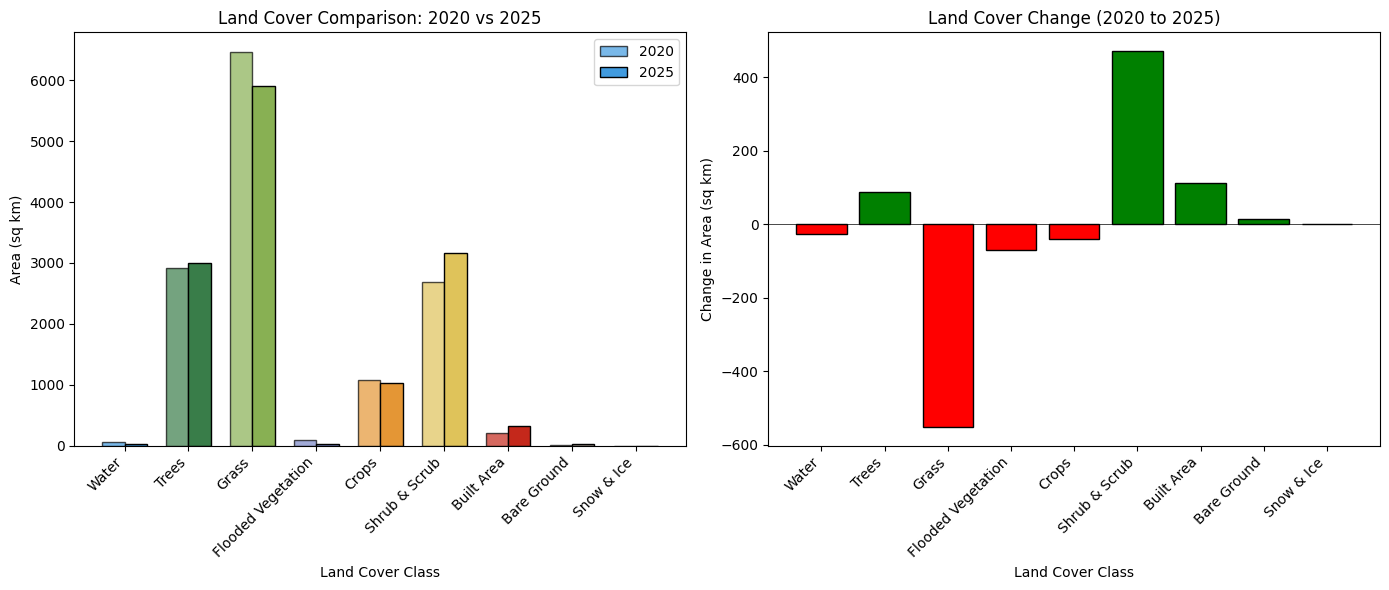

In [20]:
# Create comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart comparing both years
x = range(len(df_combined))
width = 0.35

colors = [DW_CLASSES[i]['color'] for i in df_combined['Class ID']]

axes[0].bar([i - width/2 for i in x], df_combined[f'Area {YEAR_1} (sq km)'], 
            width, label=str(YEAR_1), color=colors, alpha=0.7, edgecolor='black')
axes[0].bar([i + width/2 for i in x], df_combined[f'Area {YEAR_2} (sq km)'], 
            width, label=str(YEAR_2), color=colors, alpha=1.0, edgecolor='black')

axes[0].set_xlabel('Land Cover Class')
axes[0].set_ylabel('Area (sq km)')
axes[0].set_title(f'Land Cover Comparison: {YEAR_1} vs {YEAR_2}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_combined['Class Name'], rotation=45, ha='right')
axes[0].legend()

# Change bar chart
change_colors = ['green' if c > 0 else 'red' for c in df_combined['Change (sq km)']]
axes[1].bar(x, df_combined['Change (sq km)'], color=change_colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('Land Cover Class')
axes[1].set_ylabel('Change in Area (sq km)')
axes[1].set_title(f'Land Cover Change ({YEAR_1} to {YEAR_2})')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_combined['Class Name'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Create Change Detection Map

In [31]:
# Create a change detection image
# Areas where land cover changed
change_mask = lc_year1.neq(lc_year2)

# Create change map (hide layer selector and toolbar)
change_map = geemap.Map(layer_ctrl=False, data_ctrl=False, toolbar_ctrl=False)
change_map.centerObject(roi, zoom=10)

# Add base layer (year 2)
change_map.addLayer(lc_year2, dw_vis, f'Land Cover {YEAR_2}')

# Add change areas highlighted
change_map.addLayer(
    change_mask.selfMask(),
    {'palette': ['red']},
    'Areas of Change',
    opacity=0.7
)

# Add river
change_map.addLayer(
    river_ee.style(**{'color': RIVER_COLOR, 'width': 2}),
    {},
    'River'
)

# Add basin boundary
change_map.addLayer(
    basin_ee.style(**{'color': BASIN_COLOR, 'fillColor': '00000000', 'width': 2}),
    {},
    'Basin Boundary'
)

# Add legends
change_map.add_legend(title='Land Cover Classes', keys=legend_labels, colors=legend_colors)

reference_keys = ['Basin Boundary', 'River']
reference_colors = [BASIN_COLOR, RIVER_COLOR]
change_map.add_legend(keys=reference_keys, colors=reference_colors, position='topright')

change_map

Map(center=[-1.6207698267146633, 34.42550382624376], controls=(WidgetControl(options=['position', 'transparent…

## Calculate Change Matrix (Transition Analysis)

In [46]:
def calculate_transition_matrix(lc1, lc2, roi, scale=10):
    """
    Calculate the transition matrix between two land cover classifications.
    """
    # Combine the two classifications into a single band
    # Using formula: combined = year1 * 10 + year2
    combined = lc1.multiply(10).add(lc2)
    
    # Add area band first, then transition band (group input comes after weighted)
    area_image = ee.Image.pixelArea().divide(1e6)
    combined_with_area = area_image.addBands(combined).rename(['area', 'transition'])
    
    # Calculate areas
    transitions = combined_with_area.reduceRegion(
        reducer=ee.Reducer.sum().group(
            groupField=1,  # 'transition' band is at index 1
            groupName='transition'
        ),
        geometry=roi,
        scale=scale,
        maxPixels=1e13
    )
    
    return transitions.getInfo()['groups']

print("Calculating transition matrix (this may take a moment)...")
transitions = calculate_transition_matrix(lc_year1, lc_year2, roi)
print("Transition matrix calculation complete!")

Calculating transition matrix (this may take a moment)...
Transition matrix calculation complete!


In [47]:
# Create transition matrix DataFrame
n_classes = 9
matrix = pd.DataFrame(0.0, 
                      index=[DW_CLASSES[i]['name'] for i in range(n_classes)],
                      columns=[DW_CLASSES[i]['name'] for i in range(n_classes)])

for t in transitions:
    code = int(t['transition'])
    from_class = code // 10
    to_class = code % 10
    if from_class < n_classes and to_class < n_classes:
        matrix.iloc[from_class, to_class] = round(t['sum'], 2)

print(f"\nLand Cover Transition Matrix ({YEAR_1} to {YEAR_2})")
print(f"Rows: From class ({YEAR_1}), Columns: To class ({YEAR_2})")
print("Values in sq km\n")
matrix


Land Cover Transition Matrix (2015 to 2025)
Rows: From class (2015), Columns: To class (2025)
Values in sq km



,Water,Trees,Grass,Flooded Vegetation,Crops,Shrub & Scrub,Built Area,Bare Ground,Snow & Ice
Water,21.06,103.78,348.92,4.14,59.56,177.13,10.21,4.67,0.00
Trees,4.41,2134.01,675.11,5.67,212.67,508.75,68.22,1.05,0.00
Grass,5.34,314.72,4234.70,3.58,241.29,562.07,39.53,4.34,0.00
Flooded Vegetation,1.72,50.42,22.55,7.73,0.57,3.93,0.00,0.02,0.00
Crops,0.33,84.03,109.00,0.12,444.96,189.56,83.53,5.17,0.01
Shrub & Scrub,0.38,303.68,513.21,0.54,68.26,1711.62,26.59,7.01,0.00
Built Area,0.01,7.04,2.80,0.00,7.18,9.12,88.64,0.13,0.00
Bare Ground,0.15,0.25,6.08,0.00,2.19,2.85,0.31,4.13,0.00
Snow & Ice,0.00,0.02,0.07,0.00,0.01,0.06,0.01,0.00,0.00


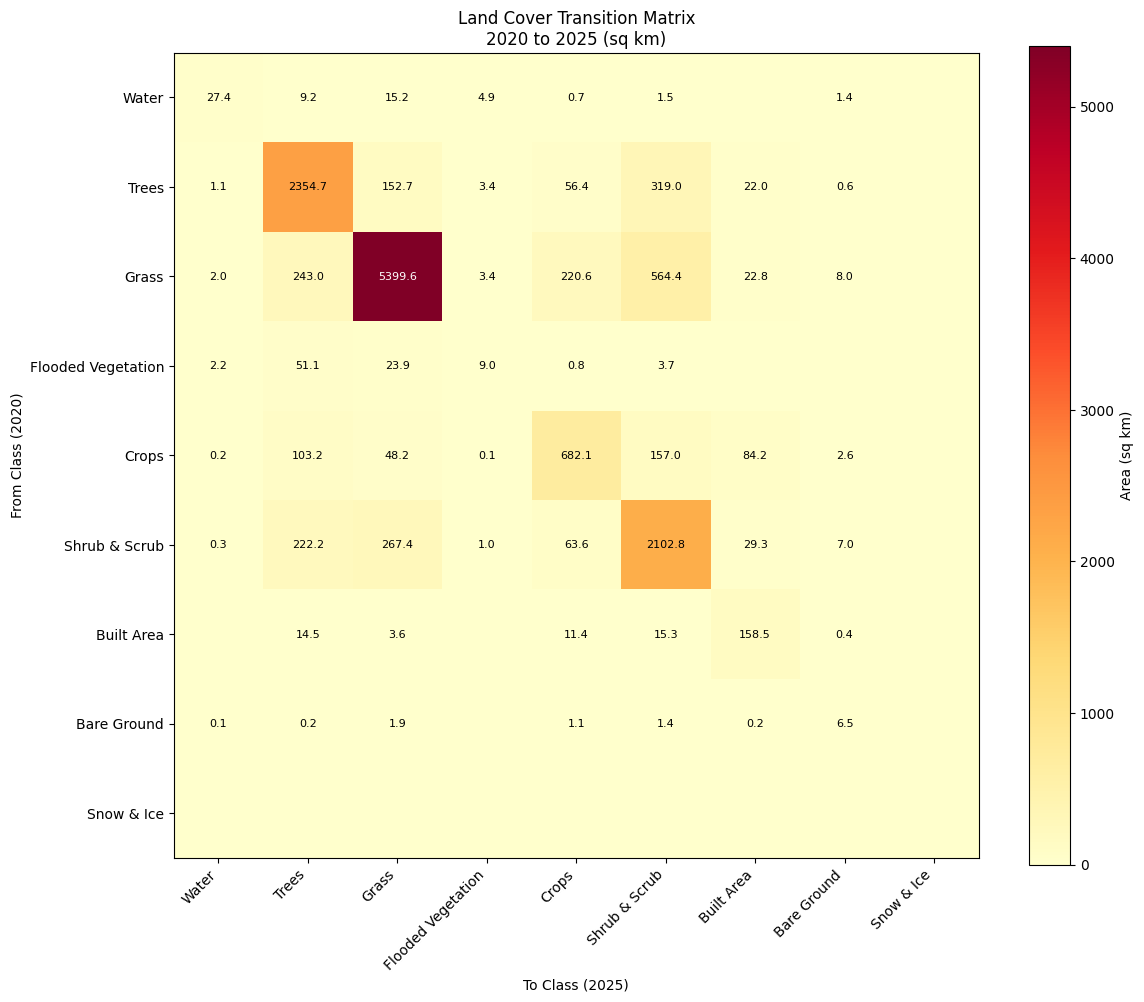

In [24]:
# Visualize transition matrix as heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(matrix.values, cmap='YlOrRd')

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(matrix.index)

ax.set_xlabel(f'To Class ({YEAR_2})')
ax.set_ylabel(f'From Class ({YEAR_1})')
ax.set_title(f'Land Cover Transition Matrix\n{YEAR_1} to {YEAR_2} (sq km)')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Area (sq km)')

# Add text annotations for significant transitions
for i in range(n_classes):
    for j in range(n_classes):
        value = matrix.iloc[i, j]
        if value > 0.1:  # Only show if > 0.1 sq km
            text_color = 'white' if value > matrix.values.max() * 0.5 else 'black'
            ax.text(j, i, f'{value:.1f}', ha='center', va='center', 
                   color=text_color, fontsize=8)

plt.tight_layout()
plt.show()

## Sankey Diagram - Land Cover Transitions

In [36]:
# Visualize transition matrix as Sankey diagram
import plotly.graph_objects as go

# Prepare data for Sankey
# Filter out transitions below threshold to reduce noise
THRESHOLD = 1.0  # sq km - adjust to filter small transitions

# Create node labels (Year1 classes on left, Year2 classes on right)
class_names = [DW_CLASSES[i]['name'] for i in range(n_classes)]
class_colors = [DW_CLASSES[i]['color'] for i in range(n_classes)]

# Nodes: first 9 are source (Year1), next 9 are target (Year2)
node_labels = [f"{name} ({YEAR_1})" for name in class_names] + [f"{name} ({YEAR_2})" for name in class_names]
node_colors = class_colors + class_colors

# Build links from transition matrix
sources = []
targets = []
values = []
link_colors = []

for i, from_class in enumerate(class_names):
    for j, to_class in enumerate(class_names):
        value = matrix.iloc[i, j]
        if value > THRESHOLD:
            sources.append(i)  # Source node index
            targets.append(j + n_classes)  # Target node index (offset by n_classes)
            values.append(value)
            # Use source class color with transparency
            hex_color = class_colors[i]
            # Convert hex to rgba
            r = int(hex_color[1:3], 16)
            g = int(hex_color[3:5], 16)
            b = int(hex_color[5:7], 16)
            link_colors.append(f'rgba({r},{g},{b},0.5)')

# Create Sankey diagram
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='black', width=0.5),
        label=node_labels,
        color=node_colors
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=link_colors
    )
)])

fig.update_layout(
    title=dict(
        text=f'Land Cover Transitions: {YEAR_1} to {YEAR_2}',
        font=dict(size=16)
    ),
    font=dict(size=12),
    height=600,
    width=1000
)

fig.show()

print(f'\nShowing transitions > {THRESHOLD} sq km')
print(f'Total transitions shown: {len(values)}')

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

## Export Results

In [48]:
# Export summary statistics to CSV
output_path = 'landuse_change_summary.csv'
df_combined.to_csv(output_path, index=False)
print(f"Summary statistics exported to: {output_path}")

# Export transition matrix
matrix_path = 'transition_matrix.csv'
matrix.to_csv(matrix_path)
print(f"Transition matrix exported to: {matrix_path}")

Summary statistics exported to: landuse_change_summary.csv
Transition matrix exported to: transition_matrix.csv


## Summary Statistics

In [26]:
# Print summary
total_area = df_combined[f'Area {YEAR_1} (sq km)'].sum()
total_changed = (matrix.values.sum() - matrix.values.diagonal().sum())

print(f"\n{'='*60}")
print(f"LAND USE CHANGE SUMMARY: {YEAR_1} to {YEAR_2}")
print(f"{'='*60}")
print(f"Total basin area: {total_area:.2f} sq km")
print(f"Total area with land cover change: {total_changed:.2f} sq km")
print(f"Percentage of basin with change: {(total_changed/total_area)*100:.2f}%")
print(f"\nMajor changes:")

# Find top changes
changes_sorted = df_combined.reindex(df_combined['Change (sq km)'].abs().sort_values(ascending=False).index)
for _, row in changes_sorted.head(5).iterrows():
    direction = 'increased' if row['Change (sq km)'] > 0 else 'decreased'
    print(f"  - {row['Class Name']}: {direction} by {abs(row['Change (sq km)']):.2f} sq km ({row['Change (%)']:.1f}%)")


LAND USE CHANGE SUMMARY: 2020 to 2025
Total basin area: 13510.96 sq km
Total area with land cover change: 2770.35 sq km
Percentage of basin with change: 20.50%

Major changes:
  - Grass: decreased by 551.30 sq km (-8.5%)
  - Shrub & Scrub: increased by 471.62 sq km (17.5%)
  - Built Area: increased by 113.25 sq km (55.6%)
  - Trees: increased by 88.06 sq km (3.0%)
  - Flooded Vegetation: decreased by 68.89 sq km (-76.0%)
